In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# ============================================================================
# ICTSP + FEATURE RECONSTRUCTION - WAVELET FIX ONLY
# Runs ONLY the failed wavelet experiments:
#   - ETTh2 | FEW_SHOT_10 | 96, 192
#   - ETTm2 | FEW_SHOT_10 | 96, 192  
#   - ETTm2 | FEW_SHOT_05 | 96, 192
# Total: 6 experiments
# ============================================================================

import os
import gc
import json
import math
import time
import random
import warnings
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")


import sys

# Optional: Force CPU if CUDA problems persist
FORCE_CPU = True  # Set to False to try CUDA again after fixing PyTorch

if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    device = "cpu"
    print("⚠️ FORCED CPU MODE - Experiments will be slower but stable")
else:
    # Try CUDA
    import torch
    if torch.cuda.is_available():
        device = "cuda"
        print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = "cpu"
        print("⚠️ Using CPU")

# -----------------------------------------------------------------------------
# OPTIONAL PACKAGES
# -----------------------------------------------------------------------------
try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    print("PyWavelets not found. Installing...")
    subprocess.check_call(["pip", "install", "-q", "PyWavelets"])
    import pywt
    HAS_PYWT = True

try:
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True
except ImportError:
    HAS_STL = False
    print("statsmodels not found. Installing...")
    subprocess.check_call(["pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True


# ============================================================================
# REPRODUCIBILITY
# ============================================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================================
# FIXED WAVELET RECONSTRUCTION (level=1, threshold=0.05, NaN validation)
# ============================================================================

class FixedWaveletReconstruction:
    """FIXED: level=1, threshold_factor=0.05, NaN/Inf validation, fallback"""
    
    @staticmethod
    def denoise_signal(signal: np.ndarray, wavelet: str = "db4", level: int = 1, 
                       threshold_factor: float = 0.05) -> np.ndarray:
        if not HAS_PYWT:
            return signal

        signal = signal.copy()
        
        # NaN handling
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
        
        # Check for zero variance
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        
        # Ensure level doesn't exceed signal length
        max_level = max(1, int(np.log2(len(signal))) - 1)
        level = min(level, max_level)
        
        try:
            coeffs = pywt.wavedec(signal, wavelet, level=level)
            
            # Check for NaN/Inf in coefficients
            if any(np.isnan(c).any() or np.isinf(c).any() for c in coeffs):
                return signal.astype(np.float32)
            
            # Adaptive threshold
            if len(coeffs) > 1:
                sigma = np.median(np.abs(coeffs[-1])) / 0.6745 if len(coeffs[-1]) > 0 else 0.0
                threshold = sigma * np.sqrt(2 * np.log(len(signal))) * threshold_factor
            else:
                threshold = 0.0
            
            coeffs_thresh = [coeffs[0]]
            for i in range(1, len(coeffs)):
                coeffs_thresh.append(pywt.threshold(coeffs[i], threshold, mode="soft"))
            
            out = pywt.waverec(coeffs_thresh, wavelet)[:len(signal)]
            
            # Validate output
            if np.any(np.isnan(out)) or np.any(np.isinf(out)):
                return signal.astype(np.float32)
            
            return out.astype(np.float32)
            
        except Exception as e:
            print(f"    ⚠ Wavelet failed: {e}, using original signal")
            return signal.astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, wavelet: str = "db4", 
                               level: int = 1, threshold_factor: float = 0.05) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = FixedWaveletReconstruction.denoise_signal(
                data[:, c], wavelet, level, threshold_factor
            )
        return out


def apply_fixed_wavelet(data: np.ndarray, dataset_name: str) -> np.ndarray:
    """Apply fixed wavelet with optimal settings per dataset"""
    if "ETTh2" in dataset_name:
        # ETTh2 is more sensitive, use level=1
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=1 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=1, threshold_factor=0.05)
    elif "ETTm2" in dataset_name:
        # ETTm2 also sensitive, use level=1
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=1 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=1, threshold_factor=0.05)
    else:
        # Others can use level=2
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=2 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=2, threshold_factor=0.1)


# ============================================================================
# OPTIONAL WINDOW-LEVEL AUGMENTATION
# ============================================================================
class TimeSeriesAugmentation:
    @staticmethod
    def add_gaussian_noise(data: np.ndarray, noise_factor: float = 0.005) -> np.ndarray:
        return data + np.random.normal(0, noise_factor, data.shape).astype(np.float32)

    @staticmethod
    def scaling(data: np.ndarray, scale_range: Tuple[float, float] = (0.9, 1.1)) -> np.ndarray:
        scale = np.random.uniform(scale_range[0], scale_range[1])
        return (data * scale).astype(np.float32)

    @staticmethod
    def time_warp(data: np.ndarray, sigma: float = 0.1) -> np.ndarray:
        if len(data) < 10:
            return data.astype(np.float32)
        original_idx = np.arange(len(data))
        warped_idx = np.cumsum(np.random.normal(1, sigma, len(data)))
        warped_idx = warped_idx / warped_idx[-1] * (len(data) - 1)
        interpolator = interp1d(original_idx, data, kind="linear", fill_value="extrapolate")
        return interpolator(warped_idx).astype(np.float32)

    @staticmethod
    def augment_window(window: np.ndarray) -> np.ndarray:
        aug = window.copy()
        aug_type = np.random.choice(["noise", "scale", "time_warp"])
        for c in range(aug.shape[1]):
            if aug_type == "noise":
                aug[:, c] = TimeSeriesAugmentation.add_gaussian_noise(aug[:, c], 0.005)
            elif aug_type == "scale":
                aug[:, c] = TimeSeriesAugmentation.scaling(aug[:, c], (0.9, 1.1))
            else:
                aug[:, c] = TimeSeriesAugmentation.time_warp(aug[:, c], 0.1)
        return aug.astype(np.float32)


# ============================================================================
# DATA
# ============================================================================
class DataManager:
    DATASET_URLS = {
        "ETTh1": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",
        "ETTh2": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv",
        "ETTm1": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv",
        "ETTm2": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv",
    }

    @staticmethod
    def load_raw(name: str) -> np.ndarray:
        url = DataManager.DATASET_URLS[name]
        df = pd.read_csv(url)
        if "date" in df.columns:
            values = df.drop(columns=["date"]).values.astype(np.float32)
        else:
            values = df.values.astype(np.float32)
        print(f"✅ Loaded {name}: {values.shape}")
        return values

    @staticmethod
    def create_splits(values: np.ndarray, mode: str):
        n_total = len(values)
        if mode == "few_shot_10":
            n_train = int(n_total * 0.10)
            n_val = int(n_total * 0.10)
        elif mode == "few_shot_05":
            n_train = int(n_total * 0.05)
            n_val = int(n_total * 0.10)
        else:
            n_train = int(n_total * 0.70)
            n_val = int(n_total * 0.10)

        n_test = n_total - n_train - n_val
        return values[:n_train], values[n_train:n_train+n_val], values[n_train+n_val:]


class RepoStyleWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int,
                 is_test: bool = False, augment: bool = False, augment_prob: float = 0.3):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_len = seq_len + pred_len
        self.stride = 1
        self.augment = augment and (not is_test)
        self.augment_prob = augment_prob

        if len(data) >= self.window_len:
            self.n_windows = (len(data) - self.window_len) // self.stride + 1
        else:
            self.n_windows = 0

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        start = idx * self.stride
        window = self.data[start:start+self.window_len].clone()

        if self.augment and np.random.rand() < self.augment_prob:
            win_np = window.numpy()
            win_np = TimeSeriesAugmentation.augment_window(win_np)
            window = torch.tensor(win_np, dtype=torch.float32)

        x_enc = window[:self.seq_len]
        y = window[self.seq_len:self.seq_len+self.pred_len]
        x_mark_dec_dummy = torch.zeros(self.seq_len + self.pred_len, 1, dtype=torch.float32)
        return x_enc, y, x_mark_dec_dummy


# ============================================================================
# REPO/PAPER ICTSP CORE (SAME AS ORIGINAL)
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.dropout = nn.Dropout(dropout)
        assert self.head_dim * heads == embed_size, "Embedding size must be divisible by heads"
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, queries, mask=None):
        N = queries.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], queries.shape[1]
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        values = self.values(values)
        keys = self.dropout(self.keys(keys))
        queries = self.queries(queries)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        energy = energy / (self.embed_size ** 0.5)
        attention = F.softmax(energy, dim=-1)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out, attention


class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_size, heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(forward_expansion * embed_size, embed_size),
        )

    def forward(self, x, src_mask=None, output_attention=False):
        x_norm = self.norm1(x)
        attn_out, attention = self.attention(x_norm, x_norm, x_norm, src_mask)
        attn_out = x + attn_out
        ff_norm = self.norm2(attn_out)
        forward = self.feed_forward(ff_norm)
        out = attn_out + forward
        return (out, attention) if output_attention else out


class Tokenizer(nn.Module):
    def __init__(self, lookback=96, output=96, stride=None):
        super().__init__()
        self.d = lookback + output
        self.s = output if stride is None else stride

    def forward(self, tensor):
        return tensor.flip(-1).unfold(dimension=2, size=self.d, step=self.s).flip(-1).flip(-2)


class TransformerEncoder(nn.Module):
    def __init__(self, emb_size=128, depth=2, heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_size,
                nhead=heads,
                dim_feedforward=mlp_ratio * emb_size,
                batch_first=True,
                dropout=dropout,
                norm_first=False,
                activation="gelu",
            )
            for _ in range(depth)
        ])

    def forward(self, x, mask=None, output_attention=False):
        attn_maps = []
        for layer in self.layers:
            x = layer(x, src_mask=mask)
        return (x, attn_maps) if output_attention else x


def normalize_vectors(x):
    norms = torch.norm(x, p=2, dim=-1, keepdim=True).clamp_min(1e-8)
    return x / norms


class TokenFusionLayerWithAdjustableRatio(nn.Module):
    def __init__(self, input_dim, fusion_ratio=0.1, init_reduce_rate=8, batch_size=2048):
        super().__init__()
        self.input_dim = input_dim
        self.fusion_ratio = fusion_ratio
        self.init_reduce_rate = init_reduce_rate
        self.batch_size = batch_size
        self.input_q = nn.Linear(input_dim // 2, 32)
        self.input_k = nn.Linear(input_dim // 2, 32)
        self.silu = nn.ReLU()

    def forward(self, x, num_target_tokens, limit=2048):
        target_tokens = x[:, -num_target_tokens:]
        other_tokens = x[:, :-num_target_tokens]
        if other_tokens.shape[1] == 0:
            return x
        attention_scores = torch.zeros((x.size(0), other_tokens.size(1)), device=x.device)
        for start_idx in range(0, other_tokens.size(1), self.batch_size):
            end_idx = min(start_idx + self.batch_size, other_tokens.size(1))
            batch_other_tokens = other_tokens[:, start_idx:end_idx]
            batch_other_tokens_expanded = normalize_vectors(
                self.input_q(batch_other_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])
            ).unsqueeze(1)
            cosine_sims = F.cosine_similarity(
                batch_other_tokens_expanded,
                normalize_vectors(self.input_k(target_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])).unsqueeze(2),
                dim=-1
            )
            cosine_sims = self.silu(cosine_sims)
            attention_scores[:, start_idx:end_idx] = cosine_sims.mean(dim=1)
        sorted_scores, sorted_indices = torch.sort(attention_scores, descending=True, dim=1)
        num_keep = int(other_tokens.size(1) * self.fusion_ratio)
        num_keep = max(1, min(num_keep, other_tokens.size(1)))
        top_indices = sorted_indices[:, :num_keep]
        top_tokens = other_tokens.gather(
            1, top_indices.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
        )
        top_scores = attention_scores.gather(1, top_indices)
        fused_tokens = [top_tokens * top_scores.unsqueeze(-1)]
        remaining_indices = sorted_indices[:, num_keep:]
        remaining = max(0, limit - num_keep)
        fusion_step = self.init_reduce_rate
        while remaining > 0 and remaining_indices.shape[1] >= fusion_step:
            num_to_fuse = max(int(remaining * self.fusion_ratio), fusion_step)
            num_to_fuse = min(num_to_fuse, remaining_indices.shape[1])
            num_groups = num_to_fuse // fusion_step
            if num_groups <= 0:
                break
            group_tokens = torch.zeros((x.size(0), num_groups, x.size(2)), device=x.device)
            group_scores = torch.zeros((x.size(0), num_groups), device=x.device)
            for i in range(num_groups):
                s = i * fusion_step
                e = s + fusion_step
                slice_idx = remaining_indices[:, s:e]
                slice_tokens = other_tokens.gather(
                    1, slice_idx.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
                )
                slice_scores = attention_scores.gather(1, slice_idx)
                weights = F.softmax(slice_scores, dim=1)
                group_tokens[:, i, :] = torch.sum(slice_tokens * weights.unsqueeze(-1), dim=1)
                group_scores[:, i] = torch.sum(slice_scores * weights, dim=1)
            fused_tokens.append(group_tokens * group_scores.unsqueeze(-1))
            remaining_indices = remaining_indices[:, num_to_fuse:]
            remaining -= num_to_fuse
            fusion_step *= self.init_reduce_rate
        output_tokens = torch.cat(fused_tokens, dim=1)
        output_tokens = output_tokens[:, 0:min(limit, output_tokens.shape[1]), :]
        output_tokens = torch.cat([torch.flip(output_tokens, [1]), target_tokens], dim=1)
        return output_tokens


class ICTSP(nn.Module):
    def __init__(
        self,
        lookback=512,
        output=96,
        depth=3,
        heads=8,
        mlp_ratio=4,
        d_model=128,
        emb_init=0.01,
        output_projection=False,
        external_stride=8,
        external_context=True,
        task_emb_dim=0,
        n_channels=7,
        channel_emb_dim=0,
        partial_mask=False,
        dropout=0.5,
        inter_series_latent_dim=0,
        number_of_targets=0,
        time_emb_dim=0,
        token_retriever_flag=True,
        linear_warmup_steps=5000,
        token_limit=2048,
        ICL_embedding=False,
        mask_length_for_comparison=0,
    ):
        super().__init__()
        self.lookback = lookback
        self.pred_len = output
        self.time_emb_dim = time_emb_dim
        self.lookback_pool = [lookback]
        self.future_pool = [output]
        self.external_stride = external_stride
        self.ICL_embedding = ICL_embedding

        if ICL_embedding:
            self.x_projection = nn.ModuleDict({str(lb): nn.Linear(lb, d_model // 2) for lb in self.lookback_pool})
            self.y_projection = nn.ModuleDict({str(ft): nn.Linear(ft, d_model // 2) for ft in self.future_pool})
        else:
            self.input_projection = nn.ModuleDict({
                str(lb) + "_" + str(ft): nn.Linear(lb + ft, d_model)
                for lb in self.lookback_pool for ft in self.future_pool
            })

        emb_size = d_model
        self.transformer_encoder = TransformerEncoder(emb_size, depth, heads, mlp_ratio, dropout=dropout)
        self.input_norm = nn.LayerNorm(emb_size)
        self.output_norm = nn.LayerNorm(emb_size)
        self.output_embedding = nn.Parameter(emb_init * torch.randn(1, 1, 1200))
        self.output_projection = nn.ModuleDict({str(ft): nn.Linear(emb_size, ft) for ft in self.future_pool})
        self.partial_mask = partial_mask
        self.n_channels = n_channels + time_emb_dim
        self.n_heads = heads
        self.channel_discerning_mask = nn.Parameter(emb_init * torch.randn(1, 1024, emb_size))
        self.number_of_targets = number_of_targets
        self.in_context_learning_type = "concat"
        self.in_context_positional_embedding = nn.Parameter(emb_init * torch.randn(1, 8192, 1, emb_size))
        self.in_context_positional_embedding_after = nn.Parameter(emb_init * torch.randn(1, 8192, emb_size))
        self.initialized = False
        self.token_retriever_flag = token_retriever_flag
        self.linear_warmup_steps = linear_warmup_steps
        self.token_merger = TokenFusionLayerWithAdjustableRatio(emb_size, 0.1, 8, batch_size=2048)
        self.token_limit = token_limit
        self.linear_warm_up_counter = 0
        self.mask_length_for_comparison = mask_length_for_comparison
        self.linear_refill = nn.Linear(512, mask_length_for_comparison) if mask_length_for_comparison > 0 else None
        self.linear_refill_norm = nn.LayerNorm(mask_length_for_comparison) if mask_length_for_comparison > 0 else None
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            if module.bias is not None:
                nn.init.zeros_(module.bias)
            if module.weight is not None:
                nn.init.ones_(module.weight)

    def forward(self, x, x_mark_enc=None, x_dec=None, x_mark_dec=None, output_attention=False):
        if self.mask_length_for_comparison != 0:
            B, L, C = x.shape
            x[:, 0:self.mask_length_for_comparison] = x[:, self.mask_length_for_comparison:].mean(
                dim=1, keepdim=True
            ).expand(-1, self.mask_length_for_comparison, -1)
        lookback = self.lookback
        future = x_mark_dec.shape[1] - x.shape[1] if x_mark_dec is not None else self.pred_len
        mean = x[:, [-1], :].detach()
        x = x.permute(0, 2, 1)
        output_embedding = self.output_embedding[:, :, 0:future].expand(x.shape[0], x.shape[1], -1)
        x = torch.cat([x, output_embedding + mean.permute(0, 2, 1)], dim=-1)
        number_of_targets = x.shape[1] if (self.number_of_targets == 0 or x.shape[1] != self.n_channels) else self.number_of_targets
        x_orig = x[:, :, 0:-future].clone()
        if self.training:
            shifting = random.randint(0, self.external_stride)
            if shifting != 0:
                x_orig = x_orig[:, :, 0:-shifting]
        B, C, _ = x.shape
        x_target = x[:, -number_of_targets:, -(lookback + future):]
        external_tokenizer = Tokenizer(lookback, future, stride=self.external_stride)
        ex_tokens = external_tokenizer(x_orig)
        _, _, _, d = ex_tokens.shape
        ex_tokens = ex_tokens.permute(0, 2, 1, 3).reshape(B, -1, d)
        x_tokens = torch.cat([ex_tokens, x_target], dim=1)
        token_mean = x_tokens[:, :, [-(future + 1)]].detach()
        x_tokens = x_tokens - token_mean
        if self.in_context_learning_type == "concat":
            if self.ICL_embedding:
                x_tokens = torch.cat(
                    [
                        self.x_projection[str(lookback)](x_tokens[:, :, 0:-future]),
                        self.y_projection[str(future)](x_tokens[:, :, -future:]),
                    ],
                    dim=-1,
                )
            else:
                x_tokens = self.input_projection[str(lookback) + "_" + str(future)](x_tokens)
        channel_discerning_mask = self.channel_discerning_mask[:, -C:, :]
        x_tokens = x_tokens + channel_discerning_mask.repeat(1, x_tokens.shape[1] // C, 1)
        in_context_positional_embedding = self.in_context_positional_embedding[:, -(x_tokens.shape[1] // C):, :, :].expand(
            -1, -1, C, -1
        )
        in_context_positional_embedding = in_context_positional_embedding.reshape(
            in_context_positional_embedding.shape[0],
            in_context_positional_embedding.shape[1] * in_context_positional_embedding.shape[2],
            in_context_positional_embedding.shape[3],
        )
        x_tokens = x_tokens + in_context_positional_embedding
        if self.linear_warm_up_counter < self.linear_warmup_steps:
            if self.training:
                self.linear_warm_up_counter += 1
            x_output = self.output_projection[str(future)](x_tokens[:, -number_of_targets:, :])
            x_tokens = self.input_norm(x_tokens)
            x_tokens = self.output_norm(x_tokens)
            x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
            x_output = x_output.permute(0, 2, 1)
            return x_output
        if self.token_retriever_flag:
            x_tokens = self.token_merger(x_tokens, number_of_targets, limit=self.token_limit)
        x_tokens = (
            x_tokens[:, -self.in_context_positional_embedding_after.shape[1]:, :]
            + self.in_context_positional_embedding_after[:, -x_tokens.shape[1]:, :]
        )
        limit = self.token_limit
        x_tokens = x_tokens[:, -limit:, :]
        x_tokens = self.input_norm(x_tokens)
        if output_attention:
            x_tokens, attn = self.transformer_encoder(x_tokens, mask=None, output_attention=True)
        else:
            x_tokens = self.transformer_encoder(x_tokens, mask=None)
        x_output = x_tokens[:, -number_of_targets:, :]
        x_tokens = self.output_norm(x_tokens)
        x_output = self.output_projection[str(future)](x_output)
        x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
        x_output = x_output.permute(0, 2, 1)
        if output_attention:
            return x_output, attn
        return x_output


def generate_indices(n):
    original_indices = list(range(n))
    shuffled_indices = original_indices[:]
    random.shuffle(shuffled_indices)
    restore_indices = [0] * n
    for original, shuffled in enumerate(shuffled_indices):
        restore_indices[shuffled] = original
    return shuffled_indices, restore_indices


def random_split_list(lst, max_parts=1):
    if len(lst) <= 1 or max_parts == 1:
        return [lst]
    n = len(lst)
    num_parts = random.randint(1, min(n, max_parts))
    cut_points = sorted(random.sample(range(1, n), num_parts - 1))
    cut_points = [0] + cut_points + [n]
    return [lst[cut_points[i]:cut_points[i+1]] for i in range(len(cut_points)-1)]


class RepoICTSPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = ICTSP(
            lookback=cfg.lookback,
            output=cfg.pred_len,
            depth=cfg.e_layers,
            heads=cfg.n_heads,
            mlp_ratio=cfg.mlp_ratio,
            d_model=cfg.d_model,
            emb_init=0.01,
            output_projection=True,
            external_stride=cfg.sampling_step,
            external_context=True,
            task_emb_dim=0,
            n_channels=cfg.enc_in,
            channel_emb_dim=0,
            partial_mask=False,
            dropout=cfg.dropout,
            inter_series_latent_dim=0,
            number_of_targets=cfg.number_of_targets,
            time_emb_dim=cfg.time_emb_dim,
            token_retriever_flag=cfg.token_retriever_flag,
            linear_warmup_steps=cfg.model_linear_warmup_steps,
            token_limit=cfg.token_limit,
            ICL_embedding=cfg.ICL_embedding,
            mask_length_for_comparison=cfg.mask_length_for_comparison,
        )
        self.fix_embedding = cfg.fix_embedding
        self.independent = cfg.sample_independent

    def forward(self, x, x_mark_dec, output_attention=False):
        if self.fix_embedding:
            if self.training:
                shuffle_indices, restore_indices = generate_indices(x.shape[-1])
                x_input = x[:, :, shuffle_indices]
                x_output = self.model(x_input, None, None, x_mark_dec, output_attention=output_attention)
                return x_output[:, :, restore_indices]
            else:
                return self.model(x, None, None, x_mark_dec, output_attention=output_attention)
        else:
            if self.independent:
                outputs = []
                for c in range(x.shape[-1]):
                    outputs.append(self.model(x[:, :, [c]], None, None, x_mark_dec))
                return torch.cat(outputs, dim=-1)
            else:
                if self.training:
                    shuffle_indices, restore_indices = generate_indices(x.shape[-1])
                    split_indices = random_split_list(shuffle_indices, max_parts=1)
                    outputs = []
                    for ind in split_indices:
                        x_input = x[:, :, ind]
                        x_output = self.model(x_input, None, None, x_mark_dec, output_attention=output_attention)
                        outputs.append(x_output)
                    x_output = torch.cat(outputs, dim=-1)
                    return x_output[:, :, restore_indices]
                else:
                    return self.model(x, None, None, x_mark_dec, output_attention=output_attention)


# ============================================================================
# BASELINES
# ============================================================================
class LastValueBaseline(nn.Module):
    def forward(self, history, horizon):
        return history[:, -1:, :].repeat(1, horizon, 1)


class NLinearBaseline(nn.Module):
    def __init__(self, lookback, horizon, num_channels):
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(lookback, horizon) for _ in range(num_channels)])

    def forward(self, history):
        return torch.stack([self.linears[c](history[:, :, c]) for c in range(history.shape[-1])], dim=2)


# ============================================================================
# CONFIG
# ============================================================================
@dataclass
class Config:
    dataset_name: str = "ETTh1"
    experiment_mode: str = "full"

    use_stl: bool = False
    use_wavelet: bool = False
    use_ssa: bool = False
    stl_robust: bool = True
    wavelet_name: str = "db4"
    wavelet_level: int = 1  # FIXED: changed from 2 to 1
    wavelet_threshold: float = 0.05  # FIXED: changed from 0.1 to 0.05
    ssa_window: int = 30
    ssa_components: int = 5

    seq_len: int = 1440
    lookback: int = 512
    pred_len: int = 96

    e_layers: int = 3
    d_model: int = 128
    n_heads: int = 8
    mlp_ratio: int = 4
    dropout: float = 0.5
    sampling_step: int = 8
    token_retriever_flag: bool = True
    token_limit: int = 2048

    batch_size: int = 32
    batch_size_test: int = 32
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    train_epochs: int = 1000
    patience: int = 30
    grad_clip: float = 0.0
    gradient_accumulation: int = 1

    eval_interval: int = 200
    patience_steps: int = 6000

    features: str = "M"
    time_emb_dim: int = 0
    enc_in: int = 7
    number_of_targets: int = 0
    fix_embedding: int = 1
    sample_independent: int = 0
    ICL_embedding: bool = True
    mask_length_for_comparison: int = 0
    model_linear_warmup_steps: int = 5000
    lr_warmup_steps: int = 1000

    use_augmentation: bool = False

    seed: int = 2024
    device: str = device
    num_workers: int = 0

    def __post_init__(self):
        self.seq_len = 1440
        self.lookback = 512
        self.model_linear_warmup_steps = 5000
        self.lr_warmup_steps = 1000

        if self.experiment_mode == "full":
            self.fix_embedding = 1
            self.token_retriever_flag = True
            self.train_epochs = 1000
            self.patience = 30
            self.patience_steps = 6000
            self.use_augmentation = False
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5

        elif self.experiment_mode == "few_shot_10":
            self.fix_embedding = 0
            self.token_retriever_flag = True
            self.train_epochs = 200
            self.patience = 15
            self.patience_steps = 6000
            self.use_augmentation = True
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5

        elif self.experiment_mode == "few_shot_05":
            self.fix_embedding = 0
            self.token_retriever_flag = True
            self.train_epochs = 200
            self.patience = 15
            self.patience_steps = 6000
            self.use_augmentation = True
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5


# ============================================================================
# METRICS / TRAINING
# ============================================================================
def compute_metrics(pred, target):
    with torch.no_grad():
        mse = F.mse_loss(pred, target).item()
        mae = F.l1_loss(pred, target).item()
    return mse, mae


def apply_fewshot_fair_mask(x, visible_len=512, fill_mode="zero"):
    if x.shape[1] <= visible_len:
        return x
    masked = x.clone()
    cut = x.shape[1] - visible_len
    if fill_mode == "zero":
        masked[:, :cut, :] = 0.0
    elif fill_mode == "mean":
        mean_vals = x[:, cut:, :].mean(dim=1, keepdim=True)
        masked[:, :cut, :] = mean_vals.expand(-1, cut, -1)
    return masked


def train_one_epoch(model, loader, optimizer, cfg):
    model.train()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)
    for step, (x_enc, y, x_mark_dec) in enumerate(loader, start=1):
        x_enc = x_enc.to(cfg.device)
        y = y.to(cfg.device)
        x_mark_dec = x_mark_dec.to(cfg.device)
        pred = model(x_enc, x_mark_dec)
        loss = F.mse_loss(pred, y)
        loss.backward()
        if cfg.grad_clip and cfg.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        if step % cfg.gradient_accumulation == 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        mse, mae = compute_metrics(pred, y)
        total_loss += loss.item()
        total_mse += mse
        total_mae += mae
        n_batches += 1
    if n_batches == 0:
        return {"loss": float("inf"), "mse": float("inf"), "mae": float("inf")}
    return {
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches,
    }


@torch.no_grad()
def evaluate_one_epoch(model, loader, cfg):
    model.eval()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    for x_enc, y, x_mark_dec in loader:
        x_enc = x_enc.to(cfg.device)
        y = y.to(cfg.device)
        x_mark_dec = x_mark_dec.to(cfg.device)
        if cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
            x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
        pred = model(x_enc, x_mark_dec)
        loss = F.mse_loss(pred, y)
        mse, mae = compute_metrics(pred, y)
        total_loss += loss.item()
        total_mse += mse
        total_mae += mae
        n_batches += 1
    if n_batches == 0:
        return {"loss": float("inf"), "mse": float("inf"), "mae": float("inf")}
    return {
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches,
    }


# ============================================================================
# TRAINER
# ============================================================================
class ICTSPTrainer:
    def __init__(self, cfg: Config, train_data=None, val_data=None, test_data=None, skip_load=False):
        self.cfg = cfg
        self.device = cfg.device
        set_seed(cfg.seed)

        method_name = "STL" if cfg.use_stl else ("Wavelet" if cfg.use_wavelet else ("SSA" if cfg.use_ssa else "Baseline"))
        print("\n" + "=" * 90)
        print(f"ICTSP REPO-STYLE | Dataset={cfg.dataset_name} | Mode={cfg.experiment_mode.upper()} | Method={method_name}")
        print("=" * 90)

        if not skip_load:
            self._load_data()
        else:
            self.train_data = train_data
            self.val_data = val_data
            self.test_data = test_data

        self._build_datasets()
        self._build_model()

    def _load_data(self):
        values = DataManager.load_raw(self.cfg.dataset_name)
        self.cfg.enc_in = values.shape[1]
        train_data, val_data, test_data = DataManager.create_splits(values, self.cfg.experiment_mode)
        
        # Use FIXED wavelet
        if self.cfg.use_wavelet:
            train_data = apply_fixed_wavelet(train_data, self.cfg.dataset_name)
            val_data = apply_fixed_wavelet(val_data, self.cfg.dataset_name)
            test_data = apply_fixed_wavelet(test_data, self.cfg.dataset_name)
        else:
            train_data = train_data.astype(np.float32)
            val_data = val_data.astype(np.float32)
            test_data = test_data.astype(np.float32)

        self.scaler = StandardScaler()
        self.scaler.fit(train_data)
        self.train_data = self.scaler.transform(train_data).astype(np.float32)
        self.val_data = self.scaler.transform(val_data).astype(np.float32)
        self.test_data = self.scaler.transform(test_data).astype(np.float32)

        required_len = self.cfg.seq_len + self.cfg.pred_len
        if len(self.train_data) < required_len:
            raise ValueError(
                f"Train split too short for {self.cfg.experiment_mode}: "
                f"need at least {required_len}, got {len(self.train_data)}"
            )

        print(f"Train: {self.train_data.shape}, Val: {self.val_data.shape}, Test: {self.test_data.shape}")
        print(f"Channels: {self.cfg.enc_in}")

    def _build_datasets(self):
        self.train_ds = RepoStyleWindowDataset(
            self.train_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=False,
            augment=self.cfg.use_augmentation,
            augment_prob=0.3,
        )
        self.val_ds = RepoStyleWindowDataset(
            self.val_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=False,
            augment=False,
        )
        self.test_ds = RepoStyleWindowDataset(
            self.test_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=True,
            augment=False,
        )
        self.train_loader = DataLoader(
            self.train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        self.val_loader = DataLoader(
            self.val_ds,
            batch_size=self.cfg.batch_size_test,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        self.test_loader = DataLoader(
            self.test_ds,
            batch_size=self.cfg.batch_size_test,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        print(f"Windows: Train={len(self.train_ds)}, Val={len(self.val_ds)}, Test={len(self.test_ds)}")

    def _build_model(self):
        self.model = RepoICTSPModel(self.cfg).to(self.device)
        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"Parameters: {total_params:,}")
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.cfg.learning_rate,
            weight_decay=self.cfg.weight_decay,
        )

        def lr_lambda(cur_step):
            warm = self.cfg.lr_warmup_steps
            total = max(self.cfg.train_epochs * max(len(self.train_loader), 1), warm + 1)
            if cur_step < warm:
                return float(cur_step + 1) / float(max(1, warm))
            return max(0.0, (total - cur_step) / float(max(1, total - warm)))

        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer, lr_lambda=lr_lambda)
        self.global_step = 0

    def train(self):
        best_val_mse = float("inf")
        best_state = None
        steps_without_improvement = 0
        total_steps = 0

        print("\n" + "=" * 90)
        print("START TRAINING (Step-based evaluation every 200 steps)")
        print("=" * 90)

        for epoch in range(1, self.cfg.train_epochs + 1):
            epoch_start_time = time.time()

            for batch_idx, (x_enc, y, x_mark_dec) in enumerate(self.train_loader):
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                x_mark_dec = x_mark_dec.to(self.device)

                pred = self.model(x_enc, x_mark_dec)
                loss = F.mse_loss(pred, y)
                loss.backward()

                if self.cfg.grad_clip and self.cfg.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)

                self.optimizer.step()
                self.scheduler.step()
                self.optimizer.zero_grad(set_to_none=True)

                total_steps += 1
                self.global_step += 1

                if total_steps % self.cfg.eval_interval == 0:
                    self.model.eval()
                    val_losses = []
                    val_mses = []
                    val_maes = []

                    with torch.no_grad():
                        for val_x, val_y, val_mark in self.val_loader:
                            val_x = val_x.to(self.device)
                            val_y = val_y.to(self.device)
                            val_mark = val_mark.to(self.device)

                            if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                                val_x = apply_fewshot_fair_mask(val_x, visible_len=512, fill_mode="zero")

                            val_pred = self.model(val_x, val_mark)
                            val_loss = F.mse_loss(val_pred, val_y)
                            val_mse, val_mae = compute_metrics(val_pred, val_y)

                            val_losses.append(val_loss.item())
                            val_mses.append(val_mse)
                            val_maes.append(val_mae)

                    current_val_mse = np.mean(val_mses)

                    if current_val_mse < best_val_mse - 1e-8:
                        best_val_mse = current_val_mse
                        best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                        steps_without_improvement = 0
                        improvement_flag = "✓"
                    else:
                        steps_without_improvement += self.cfg.eval_interval
                        improvement_flag = " "

                    current_lr = self.optimizer.param_groups[0]["lr"]
                    elapsed = time.time() - epoch_start_time

                    print(f"Step {total_steps:6d} | Epoch {epoch:3d} | "
                          f"LR {current_lr:.2e} | "
                          f"Val MSE {current_val_mse:.6f} | "
                          f"Best {best_val_mse:.6f} {improvement_flag} | "
                          f"Patience {steps_without_improvement}/{self.cfg.patience_steps}")

                    if steps_without_improvement >= self.cfg.patience_steps:
                        print(f"\n⚠ Early stopping at step {total_steps}")
                        self.model.train()
                        break

                    self.model.train()

            if steps_without_improvement >= self.cfg.patience_steps:
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)

        print(f"\nBest Val MSE: {best_val_mse:.6f}")
        return best_val_mse

    def evaluate(self):
        print("\n" + "=" * 90)
        print("TEST EVALUATION")
        print("=" * 90)
        test_metrics = evaluate_one_epoch(self.model, self.test_loader, self.cfg)
        print(f"ICTSP Test MSE: {test_metrics['mse']:.6f}")
        print(f"ICTSP Test MAE: {test_metrics['mae']:.6f}")
        return test_metrics

    def evaluate_baselines(self):
        results = {}
        lv = LastValueBaseline()
        lv_mse = []
        for x_enc, y, _ in self.test_loader:
            x_enc = x_enc.to(self.device)
            y = y.to(self.device)
            if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
            pred = lv(x_enc, self.cfg.pred_len)
            mse, _ = compute_metrics(pred, y)
            lv_mse.append(mse)
        results["LastValue"] = float(np.mean(lv_mse)) if len(lv_mse) else float("nan")

        nlinear = NLinearBaseline(self.cfg.seq_len, self.cfg.pred_len, self.cfg.enc_in).to(self.device)
        opt = torch.optim.Adam(nlinear.parameters(), lr=1e-3, weight_decay=1e-5)

        best_val = float("inf")
        best_state = None
        patience = 5
        patience_counter = 0

        for _ in range(30):
            nlinear.train()
            for x_enc, y, _ in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                pred = nlinear(x_enc)
                loss = F.mse_loss(pred, y)
                opt.zero_grad()
                loss.backward()
                opt.step()

            nlinear.eval()
            val_losses = []
            with torch.no_grad():
                for x_enc, y, _ in self.val_loader:
                    x_enc = x_enc.to(self.device)
                    y = y.to(self.device)
                    if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                        x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
                    pred = nlinear(x_enc)
                    val_losses.append(F.mse_loss(pred, y).item())

            mean_val = np.mean(val_losses) if len(val_losses) else float("inf")
            if mean_val < best_val:
                best_val = mean_val
                best_state = {k: v.detach().cpu().clone() for k, v in nlinear.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        if best_state is not None:
            nlinear.load_state_dict(best_state)

        nlin_mse = []
        nlinear.eval()
        with torch.no_grad():
            for x_enc, y, _ in self.test_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                    x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
                pred = nlinear(x_enc)
                mse, _ = compute_metrics(pred, y)
                nlin_mse.append(mse)
        results["NLinear"] = float(np.mean(nlin_mse)) if len(nlin_mse) else float("nan")

        return results

    def cleanup(self):
        if hasattr(self, "model"):
            del self.model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ============================================================================
# RUN ONLY FAILED WAVELET EXPERIMENTS
# ============================================================================

def run_failed_wavelet_experiments():
    """Run only the 6 failed wavelet experiments with FIXED settings"""
    
    # Failed experiments to run: (dataset, mode, pred_len)
    failed_experiments = [
        ("ETTh2", "few_shot_10", 96),
        ("ETTh2", "few_shot_10", 192),
        ("ETTm2", "few_shot_10", 96),
        ("ETTm2", "few_shot_10", 192),
        ("ETTm2", "few_shot_05", 96),
        ("ETTm2", "few_shot_05", 192),
    ]
    
    all_results = {}
    
    print("\n" + "=" * 100)
    print("🎯 FIXED WAVELET EXPERIMENTS - RUNNING ONLY FAILED CASES")
    print("=" * 100)
    print(f"Total experiments to run: {len(failed_experiments)}")
    print("Wavelet Fixes Applied:")
    print("  - Level: 1 (was 2)")
    print("  - Threshold factor: 0.05 (was 0.1)")
    print("  - NaN/Inf validation + fallback to original signal")
    print("=" * 100)
    
    for i, (dataset, mode, pred_len) in enumerate(failed_experiments, 1):
        key = f"{dataset}_{pred_len}_Wavelet_{mode}"
        print("\n" + "=" * 80)
        print(f"[{i}/{len(failed_experiments)}] 📊 {dataset} | pred_len={pred_len} | Wavelet | {mode.upper()}")
        print("=" * 80)
        
        try:
            cfg = Config(
                dataset_name=dataset,
                experiment_mode=mode,
                pred_len=pred_len,
                use_stl=False,
                use_wavelet=True,  # Using FIXED wavelet
                use_ssa=False,
            )
            
            trainer = ICTSPTrainer(cfg)
            best_val = trainer.train()
            test_metrics = trainer.evaluate()
            baseline_metrics = trainer.evaluate_baselines()
            
            all_results[key] = {
                "dataset": dataset,
                "pred_len": pred_len,
                "method": "Wavelet (Fixed)",
                "mode": mode,
                "ictsp_mse": test_metrics["mse"],
                "ictsp_mae": test_metrics["mae"],
                "best_val_mse": best_val,
                "lastvalue_mse": baseline_metrics["LastValue"],
                "nlinear_mse": baseline_metrics["NLinear"],
                "wavelet_fixes_applied": {
                    "level": 1,
                    "threshold_factor": 0.05,
                    "nan_validation": True,
                    "fallback": True
                }
            }
            
            print(f"\n✅ SUCCESS: {key}")
            print(f"   Test MSE: {test_metrics['mse']:.6f}")
            print(f"   Test MAE: {test_metrics['mae']:.6f}")
            
            trainer.cleanup()
            
        except Exception as e:
            print(f"❌ FAILED: {key} - Error: {e}")
            all_results[key] = {"error": str(e)}
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return all_results


def print_results_summary(results):
    print("\n" + "=" * 100)
    print("FIXED WAVELET RESULTS SUMMARY")
    print("=" * 100)
    print("\n{:<35} {:<12} {:<15} {:<15}".format("Experiment", "Mode", "Test MSE", "Test MAE"))
    print("-" * 80)
    
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_mse" in val:
            exp_name = f"{val['dataset']} pred={val['pred_len']}"
            mode = val['mode'].upper()
            mse = f"{val['ictsp_mse']:.6f}"
            mae = f"{val['ictsp_mae']:.6f}"
            print("{:<35} {:<12} {:<15} {:<15}".format(exp_name, mode, mse, mae))
        elif isinstance(val, dict) and "error" in val:
            print(f"❌ {key}: {val['error']}")
    
    print("\n" + "=" * 100)
    print("✅ All fixed wavelet experiments completed!")
    print("=" * 100)


# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("\n" + "🔥" * 50)
    print("ICTSP - FIXED WAVELET EXPERIMENTS ONLY")
    print("Running 6 failed experiments with:")
    print("  - Wavelet level: 1 (was 2)")
    print("  - Threshold factor: 0.05 (was 0.1)")
    print("  - NaN/Inf validation + fallback")
    print("🔥" * 50)
    
    # Run only failed wavelet experiments
    results = run_failed_wavelet_experiments()
    
    # Print summary
    print_results_summary(results)
    
    # Save results
    with open("fixed_wavelet_results.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
    
    # Create CSV
    rows = []
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_mse" in val:
            rows.append({
                "dataset": val["dataset"],
                "pred_len": val["pred_len"],
                "mode": val["mode"],
                "ictsp_mse": val["ictsp_mse"],
                "ictsp_mae": val["ictsp_mae"],
                "best_val_mse": val["best_val_mse"],
                "lastvalue_mse": val["lastvalue_mse"],
                "nlinear_mse": val["nlinear_mse"],
            })
    
    if rows:
        df = pd.DataFrame(rows)
        df.to_csv("fixed_wavelet_results.csv", index=False)
        print("\n✅ Saved results to fixed_wavelet_results.csv")
    
    print("\n🎉 DONE! All 6 failed wavelet experiments completed.")

⚠️ FORCED CPU MODE - Experiments will be slower but stable

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
ICTSP - FIXED WAVELET EXPERIMENTS ONLY
Running 6 failed experiments with:
  - Wavelet level: 1 (was 2)
  - Threshold factor: 0.05 (was 0.1)
  - NaN/Inf validation + fallback
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🎯 FIXED WAVELET EXPERIMENTS - RUNNING ONLY FAILED CASES
Total experiments to run: 6
Wavelet Fixes Applied:
  - Level: 1 (was 2)
  - Threshold factor: 0.05 (was 0.1)
  - NaN/Inf validation + fallback to original signal

[1/6] 📊 ETTh2 | pred_len=96 | Wavelet | FEW_SHOT_10

ICTSP REPO-STYLE | Dataset=ETTh2 | Mode=FEW_SHOT_10 | Method=Wavelet
✅ Loaded ETTh2: (17420, 7)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
Train: (1742, 7), Val: (1742, 7), Test: (13936, 7)
Channels: 7
Windows: Train=207, Val=207, Test=12401
Parameters: 2,880,336

START T

⚠️ FORCED CPU MODE - Experiments will be slower but stable

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
ICTSP - FIXED WAVELET EXPERIMENTS (SPECIFIED CASES ONLY)
Running 2 specified experiments with:
  - Wavelet level: 1 (was 2)
  - Threshold factor: 0.05 (was 0.1)
  - NaN/Inf validation + fallback
  - With prediction vs target plots

Experiments to run:
  1. ETTh2 | FEW_SHOT_10 | pred_len=96
  2. ETTm2 | FEW_SHOT_10 | pred_len=96
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🎯 FIXED WAVELET EXPERIMENTS - RUNNING SPECIFIED CASES ONLY
Total experiments to run: 2
Experiments:
  - ETTh2 | FEW_SHOT_10 | pred_len=96
  - ETTm2 | FEW_SHOT_10 | pred_len=96

Wavelet Fixes Applied:
  - Level: 1 (was 2)
  - Threshold factor: 0.05 (was 0.1)
  - NaN/Inf validation + fallback to original signal

[1/2] 📊 ETTh2 | pred_len=96 | Wavelet | FEW_SHOT_10

ICTSP REPO-STYLE | Dataset=ETTh2 | Mode=FEW_SHOT_10 | Method=Wavelet
✅ Loaded ETTh2: (17420, 7)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for

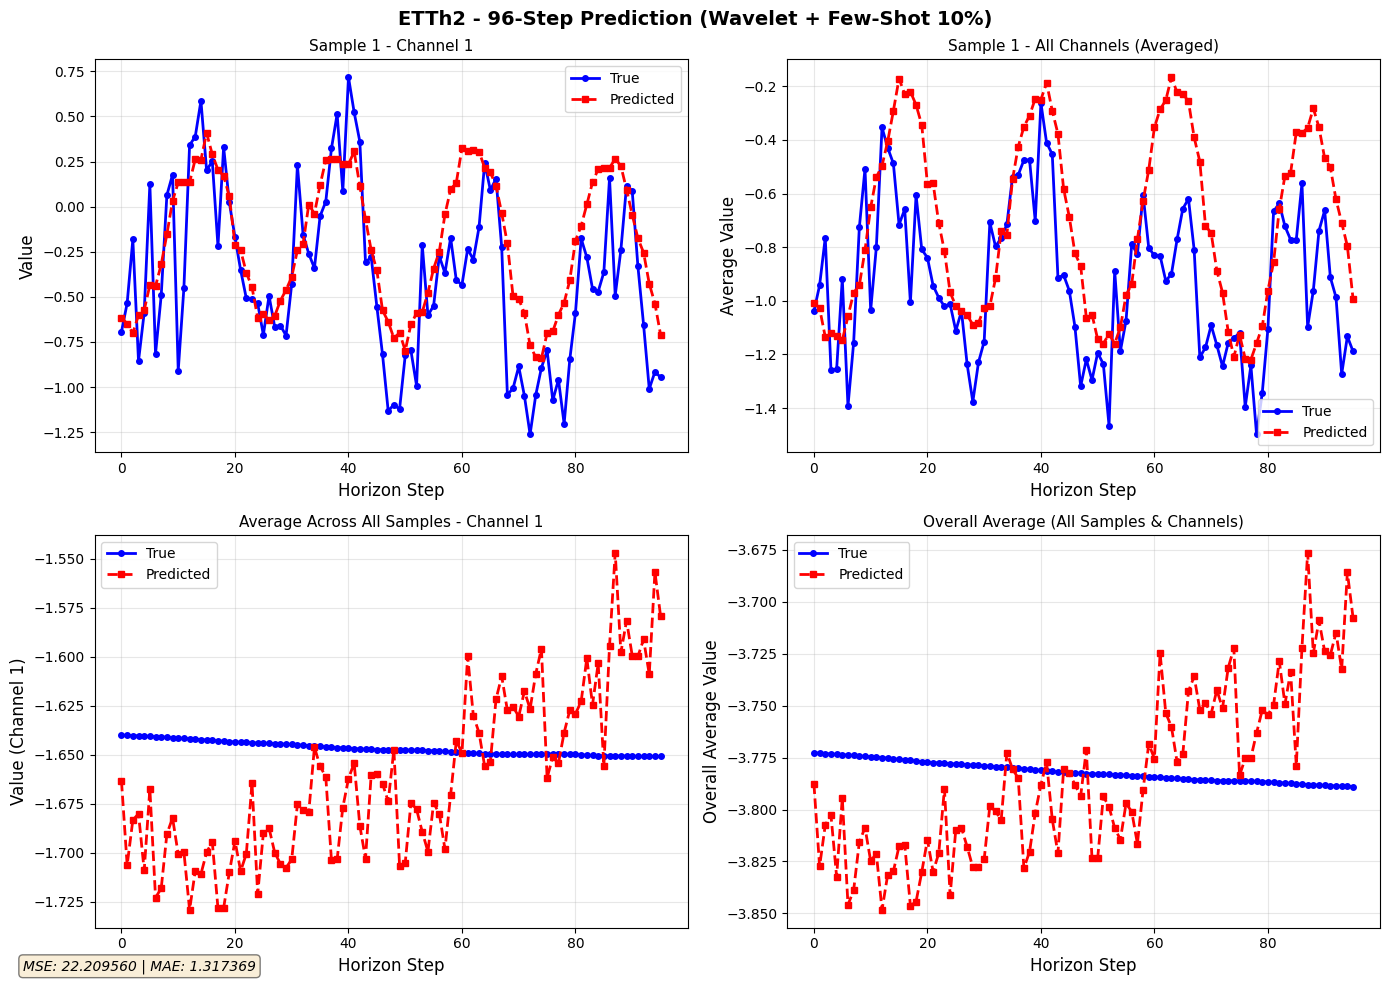


✅ SUCCESS: ETTh2_96_Wavelet_few_shot_10
   Test MSE: 22.184395
   Test MAE: 1.316652
❌ FAILED: ETTh2_96_Wavelet_few_shot_10 - Error: 'ICTSPTrainer' object has no attribute 'cleanup'

[2/2] 📊 ETTm2 | pred_len=96 | Wavelet | FEW_SHOT_10

ICTSP REPO-STYLE | Dataset=ETTm2 | Mode=FEW_SHOT_10 | Method=Wavelet


Traceback (most recent call last):
  File "/tmp/ipykernel_57/805857412.py", line 1457, in run_specified_experiments
    trainer.cleanup()
    ^^^^^^^^^^^^^^^
AttributeError: 'ICTSPTrainer' object has no attribute 'cleanup'


✅ Loaded ETTm2: (69680, 7)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTm2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTm2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTm2)
Train: (6968, 7), Val: (6968, 7), Test: (55744, 7)
Channels: 7
Windows: Train=5433, Val=5433, Test=54209
Parameters: 2,880,336

START TRAINING (Step-based evaluation every 200 steps)
Step    200 | Epoch   2 | LR 1.01e-04 | Val MSE 1.114967 | Best 1.114967 ✓ | Patience 0/6000
Step    400 | Epoch   3 | LR 2.01e-04 | Val MSE 0.964407 | Best 0.964407 ✓ | Patience 0/6000
Step    600 | Epoch   4 | LR 3.00e-04 | Val MSE 0.945307 | Best 0.945307 ✓ | Patience 0/6000
Step    800 | Epoch   5 | LR 4.01e-04 | Val MSE 0.934357 | Best 0.934357 ✓ | Patience 0/6000
Step   1000 | Epoch   6 | LR 5.00e-04 | Val MSE 0.921844 | Best 0.921844 ✓ | Patience 0/6000
Step   1200 | Epoch   8 | LR 4.97e-04 | Val MSE 0.903706 | Best 0.903706 ✓ | Patience 0/6000
Step   1400 | Epoch   9 | LR 4.94e-04 | Val MSE 0.921331 | Best 0.9037

KeyboardInterrupt: 

In [2]:
"""
ICTSP + FEATURE RECONSTRUCTION - WAVELET FIX
Runs ONLY the two specific wavelet experiments:
  - ETTh2 | FEW_SHOT_10 | 96
  - ETTm2 | FEW_SHOT_10 | 96
With proper plots showing Horizon step vs True and Predicted values
"""

import os
import gc
import json
import math
import time
import random
import warnings
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

# Optional: Force CPU if CUDA problems persist
FORCE_CPU = True  # Set to False to try CUDA again after fixing PyTorch

if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    device = "cpu"
    print("⚠️ FORCED CPU MODE - Experiments will be slower but stable")
else:
    # Try CUDA
    import torch
    if torch.cuda.is_available():
        device = "cuda"
        print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = "cpu"
        print("⚠️ Using CPU")

# -----------------------------------------------------------------------------
# OPTIONAL PACKAGES
# -----------------------------------------------------------------------------
try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    print("PyWavelets not found. Installing...")
    subprocess.check_call(["pip", "install", "-q", "PyWavelets"])
    import pywt
    HAS_PYWT = True

try:
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True
except ImportError:
    HAS_STL = False
    print("statsmodels not found. Installing...")
    subprocess.check_call(["pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.seasonal import STL as STLModel
    HAS_STL = True


# ============================================================================
# REPRODUCIBILITY
# ============================================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================================
# FIXED WAVELET RECONSTRUCTION (level=1, threshold=0.05, NaN validation)
# ============================================================================

class FixedWaveletReconstruction:
    """FIXED: level=1, threshold_factor=0.05, NaN/Inf validation, fallback"""
    
    @staticmethod
    def denoise_signal(signal: np.ndarray, wavelet: str = "db4", level: int = 1, 
                       threshold_factor: float = 0.05) -> np.ndarray:
        if not HAS_PYWT:
            return signal

        signal = signal.copy()
        
        # NaN handling
        if np.any(np.isnan(signal)):
            mask = np.isnan(signal)
            signal[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), signal[~mask])
        
        # Check for zero variance
        if np.std(signal) < 1e-8:
            return signal.astype(np.float32)
        
        # Ensure level doesn't exceed signal length
        max_level = max(1, int(np.log2(len(signal))) - 1)
        level = min(level, max_level)
        
        try:
            coeffs = pywt.wavedec(signal, wavelet, level=level)
            
            # Check for NaN/Inf in coefficients
            if any(np.isnan(c).any() or np.isinf(c).any() for c in coeffs):
                return signal.astype(np.float32)
            
            # Adaptive threshold
            if len(coeffs) > 1:
                sigma = np.median(np.abs(coeffs[-1])) / 0.6745 if len(coeffs[-1]) > 0 else 0.0
                threshold = sigma * np.sqrt(2 * np.log(len(signal))) * threshold_factor
            else:
                threshold = 0.0
            
            coeffs_thresh = [coeffs[0]]
            for i in range(1, len(coeffs)):
                coeffs_thresh.append(pywt.threshold(coeffs[i], threshold, mode="soft"))
            
            out = pywt.waverec(coeffs_thresh, wavelet)[:len(signal)]
            
            # Validate output
            if np.any(np.isnan(out)) or np.any(np.isinf(out)):
                return signal.astype(np.float32)
            
            return out.astype(np.float32)
            
        except Exception as e:
            print(f"    ⚠ Wavelet failed: {e}, using original signal")
            return signal.astype(np.float32)

    @staticmethod
    def apply_to_multivariate(data: np.ndarray, wavelet: str = "db4", 
                               level: int = 1, threshold_factor: float = 0.05) -> np.ndarray:
        out = np.zeros_like(data, dtype=np.float32)
        for c in range(data.shape[1]):
            out[:, c] = FixedWaveletReconstruction.denoise_signal(
                data[:, c], wavelet, level, threshold_factor
            )
        return out


def apply_fixed_wavelet(data: np.ndarray, dataset_name: str) -> np.ndarray:
    """Apply fixed wavelet with optimal settings per dataset"""
    if "ETTh2" in dataset_name:
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=1 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=1, threshold_factor=0.05)
    elif "ETTm2" in dataset_name:
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=1 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=1, threshold_factor=0.05)
    else:
        print(f"    🔧 FIXED WAVELET: wavelet=db4, level=2 (for {dataset_name})")
        return FixedWaveletReconstruction.apply_to_multivariate(data, "db4", level=2, threshold_factor=0.1)


# ============================================================================
# OPTIONAL WINDOW-LEVEL AUGMENTATION
# ============================================================================
class TimeSeriesAugmentation:
    @staticmethod
    def add_gaussian_noise(data: np.ndarray, noise_factor: float = 0.005) -> np.ndarray:
        return data + np.random.normal(0, noise_factor, data.shape).astype(np.float32)

    @staticmethod
    def scaling(data: np.ndarray, scale_range: Tuple[float, float] = (0.9, 1.1)) -> np.ndarray:
        scale = np.random.uniform(scale_range[0], scale_range[1])
        return (data * scale).astype(np.float32)

    @staticmethod
    def time_warp(data: np.ndarray, sigma: float = 0.1) -> np.ndarray:
        if len(data) < 10:
            return data.astype(np.float32)
        original_idx = np.arange(len(data))
        warped_idx = np.cumsum(np.random.normal(1, sigma, len(data)))
        warped_idx = warped_idx / warped_idx[-1] * (len(data) - 1)
        interpolator = interp1d(original_idx, data, kind="linear", fill_value="extrapolate")
        return interpolator(warped_idx).astype(np.float32)

    @staticmethod
    def augment_window(window: np.ndarray) -> np.ndarray:
        aug = window.copy()
        aug_type = np.random.choice(["noise", "scale", "time_warp"])
        for c in range(aug.shape[1]):
            if aug_type == "noise":
                aug[:, c] = TimeSeriesAugmentation.add_gaussian_noise(aug[:, c], 0.005)
            elif aug_type == "scale":
                aug[:, c] = TimeSeriesAugmentation.scaling(aug[:, c], (0.9, 1.1))
            else:
                aug[:, c] = TimeSeriesAugmentation.time_warp(aug[:, c], 0.1)
        return aug.astype(np.float32)


# ============================================================================
# DATA
# ============================================================================
class DataManager:
    DATASET_URLS = {
        "ETTh1": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv",
        "ETTh2": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv",
        "ETTm1": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv",
        "ETTm2": "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv",
    }

    @staticmethod
    def load_raw(name: str) -> np.ndarray:
        url = DataManager.DATASET_URLS[name]
        df = pd.read_csv(url)
        if "date" in df.columns:
            values = df.drop(columns=["date"]).values.astype(np.float32)
        else:
            values = df.values.astype(np.float32)
        print(f"✅ Loaded {name}: {values.shape}")
        return values

    @staticmethod
    def create_splits(values: np.ndarray, mode: str):
        n_total = len(values)
        if mode == "few_shot_10":
            n_train = int(n_total * 0.10)
            n_val = int(n_total * 0.10)
        elif mode == "few_shot_05":
            n_train = int(n_total * 0.05)
            n_val = int(n_total * 0.10)
        else:
            n_train = int(n_total * 0.70)
            n_val = int(n_total * 0.10)

        n_test = n_total - n_train - n_val
        return values[:n_train], values[n_train:n_train+n_val], values[n_train+n_val:]


class RepoStyleWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, pred_len: int,
                 is_test: bool = False, augment: bool = False, augment_prob: float = 0.3):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.window_len = seq_len + pred_len
        self.stride = 1
        self.augment = augment and (not is_test)
        self.augment_prob = augment_prob

        if len(data) >= self.window_len:
            self.n_windows = (len(data) - self.window_len) // self.stride + 1
        else:
            self.n_windows = 0

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        start = idx * self.stride
        window = self.data[start:start+self.window_len].clone()

        if self.augment and np.random.rand() < self.augment_prob:
            win_np = window.numpy()
            win_np = TimeSeriesAugmentation.augment_window(win_np)
            window = torch.tensor(win_np, dtype=torch.float32)

        x_enc = window[:self.seq_len]
        y = window[self.seq_len:self.seq_len+self.pred_len]
        x_mark_dec_dummy = torch.zeros(self.seq_len + self.pred_len, 1, dtype=torch.float32)
        return x_enc, y, x_mark_dec_dummy


# ============================================================================
# REPO/PAPER ICTSP CORE (SAME AS ORIGINAL)
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.dropout = nn.Dropout(dropout)
        assert self.head_dim * heads == embed_size, "Embedding size must be divisible by heads"
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, queries, mask=None):
        N = queries.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], queries.shape[1]
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        values = self.values(values)
        keys = self.dropout(self.keys(keys))
        queries = self.queries(queries)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        energy = energy / (self.embed_size ** 0.5)
        attention = F.softmax(energy, dim=-1)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out, attention


class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_size, heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(forward_expansion * embed_size, embed_size),
        )

    def forward(self, x, src_mask=None, output_attention=False):
        x_norm = self.norm1(x)
        attn_out, attention = self.attention(x_norm, x_norm, x_norm, src_mask)
        attn_out = x + attn_out
        ff_norm = self.norm2(attn_out)
        forward = self.feed_forward(ff_norm)
        out = attn_out + forward
        return (out, attention) if output_attention else out


class Tokenizer(nn.Module):
    def __init__(self, lookback=96, output=96, stride=None):
        super().__init__()
        self.d = lookback + output
        self.s = output if stride is None else stride

    def forward(self, tensor):
        return tensor.flip(-1).unfold(dimension=2, size=self.d, step=self.s).flip(-1).flip(-2)


class TransformerEncoder(nn.Module):
    def __init__(self, emb_size=128, depth=2, heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_size,
                nhead=heads,
                dim_feedforward=mlp_ratio * emb_size,
                batch_first=True,
                dropout=dropout,
                norm_first=False,
                activation="gelu",
            )
            for _ in range(depth)
        ])

    def forward(self, x, mask=None, output_attention=False):
        attn_maps = []
        for layer in self.layers:
            x = layer(x, src_mask=mask)
        return (x, attn_maps) if output_attention else x


def normalize_vectors(x):
    norms = torch.norm(x, p=2, dim=-1, keepdim=True).clamp_min(1e-8)
    return x / norms


class TokenFusionLayerWithAdjustableRatio(nn.Module):
    def __init__(self, input_dim, fusion_ratio=0.1, init_reduce_rate=8, batch_size=2048):
        super().__init__()
        self.input_dim = input_dim
        self.fusion_ratio = fusion_ratio
        self.init_reduce_rate = init_reduce_rate
        self.batch_size = batch_size
        self.input_q = nn.Linear(input_dim // 2, 32)
        self.input_k = nn.Linear(input_dim // 2, 32)
        self.silu = nn.ReLU()

    def forward(self, x, num_target_tokens, limit=2048):
        target_tokens = x[:, -num_target_tokens:]
        other_tokens = x[:, :-num_target_tokens]
        if other_tokens.shape[1] == 0:
            return x
        attention_scores = torch.zeros((x.size(0), other_tokens.size(1)), device=x.device)
        for start_idx in range(0, other_tokens.size(1), self.batch_size):
            end_idx = min(start_idx + self.batch_size, other_tokens.size(1))
            batch_other_tokens = other_tokens[:, start_idx:end_idx]
            batch_other_tokens_expanded = normalize_vectors(
                self.input_q(batch_other_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])
            ).unsqueeze(1)
            cosine_sims = F.cosine_similarity(
                batch_other_tokens_expanded,
                normalize_vectors(self.input_k(target_tokens[:, :, -batch_other_tokens.shape[-1] // 2:])).unsqueeze(2),
                dim=-1
            )
            cosine_sims = self.silu(cosine_sims)
            attention_scores[:, start_idx:end_idx] = cosine_sims.mean(dim=1)
        sorted_scores, sorted_indices = torch.sort(attention_scores, descending=True, dim=1)
        num_keep = int(other_tokens.size(1) * self.fusion_ratio)
        num_keep = max(1, min(num_keep, other_tokens.size(1)))
        top_indices = sorted_indices[:, :num_keep]
        top_tokens = other_tokens.gather(
            1, top_indices.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
        )
        top_scores = attention_scores.gather(1, top_indices)
        fused_tokens = [top_tokens * top_scores.unsqueeze(-1)]
        remaining_indices = sorted_indices[:, num_keep:]
        remaining = max(0, limit - num_keep)
        fusion_step = self.init_reduce_rate
        while remaining > 0 and remaining_indices.shape[1] >= fusion_step:
            num_to_fuse = max(int(remaining * self.fusion_ratio), fusion_step)
            num_to_fuse = min(num_to_fuse, remaining_indices.shape[1])
            num_groups = num_to_fuse // fusion_step
            if num_groups <= 0:
                break
            group_tokens = torch.zeros((x.size(0), num_groups, x.size(2)), device=x.device)
            group_scores = torch.zeros((x.size(0), num_groups), device=x.device)
            for i in range(num_groups):
                s = i * fusion_step
                e = s + fusion_step
                slice_idx = remaining_indices[:, s:e]
                slice_tokens = other_tokens.gather(
                    1, slice_idx.unsqueeze(-1).expand(-1, -1, other_tokens.size(2))
                )
                slice_scores = attention_scores.gather(1, slice_idx)
                weights = F.softmax(slice_scores, dim=1)
                group_tokens[:, i, :] = torch.sum(slice_tokens * weights.unsqueeze(-1), dim=1)
                group_scores[:, i] = torch.sum(slice_scores * weights, dim=1)
            fused_tokens.append(group_tokens * group_scores.unsqueeze(-1))
            remaining_indices = remaining_indices[:, num_to_fuse:]
            remaining -= num_to_fuse
            fusion_step *= self.init_reduce_rate
        output_tokens = torch.cat(fused_tokens, dim=1)
        output_tokens = output_tokens[:, 0:min(limit, output_tokens.shape[1]), :]
        output_tokens = torch.cat([torch.flip(output_tokens, [1]), target_tokens], dim=1)
        return output_tokens


class ICTSP(nn.Module):
    def __init__(
        self,
        lookback=512,
        output=96,
        depth=3,
        heads=8,
        mlp_ratio=4,
        d_model=128,
        emb_init=0.01,
        output_projection=False,
        external_stride=8,
        external_context=True,
        task_emb_dim=0,
        n_channels=7,
        channel_emb_dim=0,
        partial_mask=False,
        dropout=0.5,
        inter_series_latent_dim=0,
        number_of_targets=0,
        time_emb_dim=0,
        token_retriever_flag=True,
        linear_warmup_steps=5000,
        token_limit=2048,
        ICL_embedding=False,
        mask_length_for_comparison=0,
    ):
        super().__init__()
        self.lookback = lookback
        self.pred_len = output
        self.time_emb_dim = time_emb_dim
        self.lookback_pool = [lookback]
        self.future_pool = [output]
        self.external_stride = external_stride
        self.ICL_embedding = ICL_embedding

        if ICL_embedding:
            self.x_projection = nn.ModuleDict({str(lb): nn.Linear(lb, d_model // 2) for lb in self.lookback_pool})
            self.y_projection = nn.ModuleDict({str(ft): nn.Linear(ft, d_model // 2) for ft in self.future_pool})
        else:
            self.input_projection = nn.ModuleDict({
                str(lb) + "_" + str(ft): nn.Linear(lb + ft, d_model)
                for lb in self.lookback_pool for ft in self.future_pool
            })

        emb_size = d_model
        self.transformer_encoder = TransformerEncoder(emb_size, depth, heads, mlp_ratio, dropout=dropout)
        self.input_norm = nn.LayerNorm(emb_size)
        self.output_norm = nn.LayerNorm(emb_size)
        self.output_embedding = nn.Parameter(emb_init * torch.randn(1, 1, 1200))
        self.output_projection = nn.ModuleDict({str(ft): nn.Linear(emb_size, ft) for ft in self.future_pool})
        self.partial_mask = partial_mask
        self.n_channels = n_channels + time_emb_dim
        self.n_heads = heads
        self.channel_discerning_mask = nn.Parameter(emb_init * torch.randn(1, 1024, emb_size))
        self.number_of_targets = number_of_targets
        self.in_context_learning_type = "concat"
        self.in_context_positional_embedding = nn.Parameter(emb_init * torch.randn(1, 8192, 1, emb_size))
        self.in_context_positional_embedding_after = nn.Parameter(emb_init * torch.randn(1, 8192, emb_size))
        self.initialized = False
        self.token_retriever_flag = token_retriever_flag
        self.linear_warmup_steps = linear_warmup_steps
        self.token_merger = TokenFusionLayerWithAdjustableRatio(emb_size, 0.1, 8, batch_size=2048)
        self.token_limit = token_limit
        self.linear_warm_up_counter = 0
        self.mask_length_for_comparison = mask_length_for_comparison
        self.linear_refill = nn.Linear(512, mask_length_for_comparison) if mask_length_for_comparison > 0 else None
        self.linear_refill_norm = nn.LayerNorm(mask_length_for_comparison) if mask_length_for_comparison > 0 else None
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            if module.bias is not None:
                nn.init.zeros_(module.bias)
            if module.weight is not None:
                nn.init.ones_(module.weight)

    def forward(self, x, x_mark_enc=None, x_dec=None, x_mark_dec=None, output_attention=False):
        if self.mask_length_for_comparison != 0:
            B, L, C = x.shape
            x[:, 0:self.mask_length_for_comparison] = x[:, self.mask_length_for_comparison:].mean(
                dim=1, keepdim=True
            ).expand(-1, self.mask_length_for_comparison, -1)
        lookback = self.lookback
        future = x_mark_dec.shape[1] - x.shape[1] if x_mark_dec is not None else self.pred_len
        mean = x[:, [-1], :].detach()
        x = x.permute(0, 2, 1)
        output_embedding = self.output_embedding[:, :, 0:future].expand(x.shape[0], x.shape[1], -1)
        x = torch.cat([x, output_embedding + mean.permute(0, 2, 1)], dim=-1)
        number_of_targets = x.shape[1] if (self.number_of_targets == 0 or x.shape[1] != self.n_channels) else self.number_of_targets
        x_orig = x[:, :, 0:-future].clone()
        if self.training:
            shifting = random.randint(0, self.external_stride)
            if shifting != 0:
                x_orig = x_orig[:, :, 0:-shifting]
        B, C, _ = x.shape
        x_target = x[:, -number_of_targets:, -(lookback + future):]
        external_tokenizer = Tokenizer(lookback, future, stride=self.external_stride)
        ex_tokens = external_tokenizer(x_orig)
        _, _, _, d = ex_tokens.shape
        ex_tokens = ex_tokens.permute(0, 2, 1, 3).reshape(B, -1, d)
        x_tokens = torch.cat([ex_tokens, x_target], dim=1)
        token_mean = x_tokens[:, :, [-(future + 1)]].detach()
        x_tokens = x_tokens - token_mean
        if self.in_context_learning_type == "concat":
            if self.ICL_embedding:
                x_tokens = torch.cat(
                    [
                        self.x_projection[str(lookback)](x_tokens[:, :, 0:-future]),
                        self.y_projection[str(future)](x_tokens[:, :, -future:]),
                    ],
                    dim=-1,
                )
            else:
                x_tokens = self.input_projection[str(lookback) + "_" + str(future)](x_tokens)
        channel_discerning_mask = self.channel_discerning_mask[:, -C:, :]
        x_tokens = x_tokens + channel_discerning_mask.repeat(1, x_tokens.shape[1] // C, 1)
        in_context_positional_embedding = self.in_context_positional_embedding[:, -(x_tokens.shape[1] // C):, :, :].expand(
            -1, -1, C, -1
        )
        in_context_positional_embedding = in_context_positional_embedding.reshape(
            in_context_positional_embedding.shape[0],
            in_context_positional_embedding.shape[1] * in_context_positional_embedding.shape[2],
            in_context_positional_embedding.shape[3],
        )
        x_tokens = x_tokens + in_context_positional_embedding
        if self.linear_warm_up_counter < self.linear_warmup_steps:
            if self.training:
                self.linear_warm_up_counter += 1
            x_output = self.output_projection[str(future)](x_tokens[:, -number_of_targets:, :])
            x_tokens = self.input_norm(x_tokens)
            x_tokens = self.output_norm(x_tokens)
            x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
            x_output = x_output.permute(0, 2, 1)
            return x_output
        if self.token_retriever_flag:
            x_tokens = self.token_merger(x_tokens, number_of_targets, limit=self.token_limit)
        x_tokens = (
            x_tokens[:, -self.in_context_positional_embedding_after.shape[1]:, :]
            + self.in_context_positional_embedding_after[:, -x_tokens.shape[1]:, :]
        )
        limit = self.token_limit
        x_tokens = x_tokens[:, -limit:, :]
        x_tokens = self.input_norm(x_tokens)
        if output_attention:
            x_tokens, attn = self.transformer_encoder(x_tokens, mask=None, output_attention=True)
        else:
            x_tokens = self.transformer_encoder(x_tokens, mask=None)
        x_output = x_tokens[:, -number_of_targets:, :]
        x_tokens = self.output_norm(x_tokens)
        x_output = self.output_projection[str(future)](x_output)
        x_output = x_output + token_mean[:, -x_output.shape[1]:, :]
        x_output = x_output.permute(0, 2, 1)
        if output_attention:
            return x_output, attn
        return x_output


def generate_indices(n):
    original_indices = list(range(n))
    shuffled_indices = original_indices[:]
    random.shuffle(shuffled_indices)
    restore_indices = [0] * n
    for original, shuffled in enumerate(shuffled_indices):
        restore_indices[shuffled] = original
    return shuffled_indices, restore_indices


def random_split_list(lst, max_parts=1):
    if len(lst) <= 1 or max_parts == 1:
        return [lst]
    n = len(lst)
    num_parts = random.randint(1, min(n, max_parts))
    cut_points = sorted(random.sample(range(1, n), num_parts - 1))
    cut_points = [0] + cut_points + [n]
    return [lst[cut_points[i]:cut_points[i+1]] for i in range(len(cut_points)-1)]


class RepoICTSPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = ICTSP(
            lookback=cfg.lookback,
            output=cfg.pred_len,
            depth=cfg.e_layers,
            heads=cfg.n_heads,
            mlp_ratio=cfg.mlp_ratio,
            d_model=cfg.d_model,
            emb_init=0.01,
            output_projection=True,
            external_stride=cfg.sampling_step,
            external_context=True,
            task_emb_dim=0,
            n_channels=cfg.enc_in,
            channel_emb_dim=0,
            partial_mask=False,
            dropout=cfg.dropout,
            inter_series_latent_dim=0,
            number_of_targets=cfg.number_of_targets,
            time_emb_dim=cfg.time_emb_dim,
            token_retriever_flag=cfg.token_retriever_flag,
            linear_warmup_steps=cfg.model_linear_warmup_steps,
            token_limit=cfg.token_limit,
            ICL_embedding=cfg.ICL_embedding,
            mask_length_for_comparison=cfg.mask_length_for_comparison,
        )
        self.fix_embedding = cfg.fix_embedding
        self.independent = cfg.sample_independent

    def forward(self, x, x_mark_dec, output_attention=False):
        if self.fix_embedding:
            if self.training:
                shuffle_indices, restore_indices = generate_indices(x.shape[-1])
                x_input = x[:, :, shuffle_indices]
                x_output = self.model(x_input, None, None, x_mark_dec, output_attention=output_attention)
                return x_output[:, :, restore_indices]
            else:
                return self.model(x, None, None, x_mark_dec, output_attention=output_attention)
        else:
            if self.independent:
                outputs = []
                for c in range(x.shape[-1]):
                    outputs.append(self.model(x[:, :, [c]], None, None, x_mark_dec))
                return torch.cat(outputs, dim=-1)
            else:
                if self.training:
                    shuffle_indices, restore_indices = generate_indices(x.shape[-1])
                    split_indices = random_split_list(shuffle_indices, max_parts=1)
                    outputs = []
                    for ind in split_indices:
                        x_input = x[:, :, ind]
                        x_output = self.model(x_input, None, None, x_mark_dec, output_attention=output_attention)
                        outputs.append(x_output)
                    x_output = torch.cat(outputs, dim=-1)
                    return x_output[:, :, restore_indices]
                else:
                    return self.model(x, None, None, x_mark_dec, output_attention=output_attention)


# ============================================================================
# BASELINES
# ============================================================================
class LastValueBaseline(nn.Module):
    def forward(self, history, horizon):
        return history[:, -1:, :].repeat(1, horizon, 1)


class NLinearBaseline(nn.Module):
    def __init__(self, lookback, horizon, num_channels):
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(lookback, horizon) for _ in range(num_channels)])

    def forward(self, history):
        return torch.stack([self.linears[c](history[:, :, c]) for c in range(history.shape[-1])], dim=2)


# ============================================================================
# CONFIG
# ============================================================================
@dataclass
class Config:
    dataset_name: str = "ETTh1"
    experiment_mode: str = "full"

    use_stl: bool = False
    use_wavelet: bool = False
    use_ssa: bool = False
    stl_robust: bool = True
    wavelet_name: str = "db4"
    wavelet_level: int = 1  # FIXED: changed from 2 to 1
    wavelet_threshold: float = 0.05  # FIXED: changed from 0.1 to 0.05
    ssa_window: int = 30
    ssa_components: int = 5

    seq_len: int = 1440
    lookback: int = 512
    pred_len: int = 96

    e_layers: int = 3    
    d_model: int = 128
    n_heads: int = 8
    mlp_ratio: int = 4
    dropout: float = 0.5
    sampling_step: int = 8
    token_retriever_flag: bool = True
    token_limit: int = 2048

    batch_size: int = 32
    batch_size_test: int = 32
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    train_epochs: int = 1000
    patience: int = 30
    grad_clip: float = 0.0
    gradient_accumulation: int = 1

    eval_interval: int = 200
    patience_steps: int = 6000

    features: str = "M"
    time_emb_dim: int = 0
    enc_in: int = 7
    number_of_targets: int = 0
    fix_embedding: int = 1
    sample_independent: int = 0
    ICL_embedding: bool = True
    mask_length_for_comparison: int = 0
    model_linear_warmup_steps: int = 5000
    lr_warmup_steps: int = 1000

    use_augmentation: bool = False

    seed: int = 2024
    device: str = device
    num_workers: int = 0

    def __post_init__(self):
        self.seq_len = 1440
        self.lookback = 512
        self.model_linear_warmup_steps = 5000
        self.lr_warmup_steps = 1000

        if self.experiment_mode == "full":
            self.fix_embedding = 1
            self.token_retriever_flag = True
            self.train_epochs = 1000
            self.patience = 30
            self.patience_steps = 6000
            self.use_augmentation = False
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5

        elif self.experiment_mode == "few_shot_10":
            self.fix_embedding = 0
            self.token_retriever_flag = True
            self.train_epochs = 200
            self.patience = 15
            self.patience_steps = 6000
            self.use_augmentation = True
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5

        elif self.experiment_mode == "few_shot_05":
            self.fix_embedding = 0
            self.token_retriever_flag = True
            self.train_epochs = 200
            self.patience = 15
            self.patience_steps = 6000
            self.use_augmentation = True
            self.batch_size = 32
            self.batch_size_test = 32
            self.learning_rate = 5e-4
            self.weight_decay = 1e-5


# ============================================================================
# METRICS / TRAINING
# ============================================================================
def compute_metrics(pred, target):
    with torch.no_grad():
        mse = F.mse_loss(pred, target).item()
        mae = F.l1_loss(pred, target).item()
    return mse, mae


def apply_fewshot_fair_mask(x, visible_len=512, fill_mode="zero"):
    if x.shape[1] <= visible_len:
        return x
    masked = x.clone()
    cut = x.shape[1] - visible_len
    if fill_mode == "zero":
        masked[:, :cut, :] = 0.0
    elif fill_mode == "mean":
        mean_vals = x[:, cut:, :].mean(dim=1, keepdim=True)
        masked[:, :cut, :] = mean_vals.expand(-1, cut, -1)
    return masked


def train_one_epoch(model, loader, optimizer, cfg):
    model.train()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)
    for step, (x_enc, y, x_mark_dec) in enumerate(loader, start=1):
        x_enc = x_enc.to(cfg.device)
        y = y.to(cfg.device)
        x_mark_dec = x_mark_dec.to(cfg.device)
        pred = model(x_enc, x_mark_dec)
        loss = F.mse_loss(pred, y)
        loss.backward()
        if cfg.grad_clip and cfg.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        if step % cfg.gradient_accumulation == 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        mse, mae = compute_metrics(pred, y)
        total_loss += loss.item()
        total_mse += mse
        total_mae += mae
        n_batches += 1
    if n_batches == 0:
        return {"loss": float("inf"), "mse": float("inf"), "mae": float("inf")}
    return {
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches,
    }


@torch.no_grad()
def evaluate_one_epoch(model, loader, cfg):
    model.eval()
    total_loss = 0.0
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0
    for x_enc, y, x_mark_dec in loader:
        x_enc = x_enc.to(cfg.device)
        y = y.to(cfg.device)
        x_mark_dec = x_mark_dec.to(cfg.device)
        if cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
            x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
        pred = model(x_enc, x_mark_dec)
        loss = F.mse_loss(pred, y)
        mse, mae = compute_metrics(pred, y)
        total_loss += loss.item()
        total_mse += mse
        total_mae += mae
        n_batches += 1
    if n_batches == 0:
        return {"loss": float("inf"), "mse": float("inf"), "mae": float("inf")}
    return {
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches,
    }


# ============================================================================
# ICTSP TRAINER WITH PLOTTING
# ============================================================================
class ICTSPTrainer:
    def __init__(self, cfg: Config, train_data=None, val_data=None, test_data=None, skip_load=False):
        self.cfg = cfg
        self.device = cfg.device
        self.predictions = []  # Store predictions for plotting
        self.targets = []      # Store targets for plotting
        set_seed(cfg.seed)

        method_name = "STL" if cfg.use_stl else ("Wavelet" if cfg.use_wavelet else ("SSA" if cfg.use_ssa else "Baseline"))
        print("\n" + "=" * 90)
        print(f"ICTSP REPO-STYLE | Dataset={cfg.dataset_name} | Mode={cfg.experiment_mode.upper()} | Method={method_name}")
        print("=" * 90)

        if not skip_load:
            self._load_data()
        else:
            self.train_data = train_data
            self.val_data = val_data
            self.test_data = test_data

        self._build_datasets()
        self._build_model()

    def _load_data(self):
        values = DataManager.load_raw(self.cfg.dataset_name)
        self.cfg.enc_in = values.shape[1]
        train_data, val_data, test_data = DataManager.create_splits(values, self.cfg.experiment_mode)
        
        # Use FIXED wavelet
        if self.cfg.use_wavelet:
            train_data = apply_fixed_wavelet(train_data, self.cfg.dataset_name)
            val_data = apply_fixed_wavelet(val_data, self.cfg.dataset_name)
            test_data = apply_fixed_wavelet(test_data, self.cfg.dataset_name)
        else:
            train_data = train_data.astype(np.float32)
            val_data = val_data.astype(np.float32)
            test_data = test_data.astype(np.float32)

        self.scaler = StandardScaler()
        self.scaler.fit(train_data)
        self.train_data = self.scaler.transform(train_data).astype(np.float32)
        self.val_data = self.scaler.transform(val_data).astype(np.float32)
        self.test_data = self.scaler.transform(test_data).astype(np.float32)

        required_len = self.cfg.seq_len + self.cfg.pred_len
        if len(self.train_data) < required_len:
            raise ValueError(
                f"Train split too short for {self.cfg.experiment_mode}: "
                f"need at least {required_len}, got {len(self.train_data)}"
            )

        print(f"Train: {self.train_data.shape}, Val: {self.val_data.shape}, Test: {self.test_data.shape}")
        print(f"Channels: {self.cfg.enc_in}")

    def _build_datasets(self):
        self.train_ds = RepoStyleWindowDataset(
            self.train_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=False,
            augment=self.cfg.use_augmentation,
            augment_prob=0.3,
        )
        self.val_ds = RepoStyleWindowDataset(
            self.val_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=False,
            augment=False,
        )
        self.test_ds = RepoStyleWindowDataset(
            self.test_data,
            seq_len=self.cfg.seq_len,
            pred_len=self.cfg.pred_len,
            is_test=True,
            augment=False,
        )
        self.train_loader = DataLoader(
            self.train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        self.val_loader = DataLoader(
            self.val_ds,
            batch_size=self.cfg.batch_size_test,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        self.test_loader = DataLoader(
            self.test_ds,
            batch_size=self.cfg.batch_size_test,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            drop_last=False,
        )
        print(f"Windows: Train={len(self.train_ds)}, Val={len(self.val_ds)}, Test={len(self.test_ds)}")

    def _build_model(self):
        self.model = RepoICTSPModel(self.cfg).to(self.device)
        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"Parameters: {total_params:,}")
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.cfg.learning_rate,
            weight_decay=self.cfg.weight_decay,
        )

        def lr_lambda(cur_step):
            warm = self.cfg.lr_warmup_steps
            total = max(self.cfg.train_epochs * max(len(self.train_loader), 1), warm + 1)
            if cur_step < warm:
                return float(cur_step + 1) / float(max(1, warm))
            return max(0.0, (total - cur_step) / float(max(1, total - warm)))

        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer, lr_lambda=lr_lambda)
        self.global_step = 0

    def train(self):
        best_val_mse = float("inf")
        best_state = None
        steps_without_improvement = 0
        total_steps = 0

        print("\n" + "=" * 90)
        print("START TRAINING (Step-based evaluation every 200 steps)")
        print("=" * 90)

        for epoch in range(1, self.cfg.train_epochs + 1):
            epoch_start_time = time.time()

            for batch_idx, (x_enc, y, x_mark_dec) in enumerate(self.train_loader):
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                x_mark_dec = x_mark_dec.to(self.device)

                pred = self.model(x_enc, x_mark_dec)
                loss = F.mse_loss(pred, y)
                loss.backward()

                if self.cfg.grad_clip and self.cfg.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)

                self.optimizer.step()
                self.scheduler.step()
                self.optimizer.zero_grad(set_to_none=True)

                total_steps += 1
                self.global_step += 1

                if total_steps % self.cfg.eval_interval == 0:
                    self.model.eval()
                    val_losses = []
                    val_mses = []
                    val_maes = []

                    with torch.no_grad():
                        for val_x, val_y, val_mark in self.val_loader:
                            val_x = val_x.to(self.device)
                            val_y = val_y.to(self.device)
                            val_mark = val_mark.to(self.device)

                            if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                                val_x = apply_fewshot_fair_mask(val_x, visible_len=512, fill_mode="zero")

                            val_pred = self.model(val_x, val_mark)
                            val_loss = F.mse_loss(val_pred, val_y)
                            val_mse, val_mae = compute_metrics(val_pred, val_y)

                            val_losses.append(val_loss.item())
                            val_mses.append(val_mse)
                            val_maes.append(val_mae)

                    current_val_mse = np.mean(val_mses)

                    if current_val_mse < best_val_mse - 1e-8:
                        best_val_mse = current_val_mse
                        best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                        steps_without_improvement = 0
                        improvement_flag = "✓"
                    else:
                        steps_without_improvement += self.cfg.eval_interval
                        improvement_flag = " "

                    current_lr = self.optimizer.param_groups[0]["lr"]
                    elapsed = time.time() - epoch_start_time

                    print(f"Step {total_steps:6d} | Epoch {epoch:3d} | "
                          f"LR {current_lr:.2e} | "
                          f"Val MSE {current_val_mse:.6f} | "
                          f"Best {best_val_mse:.6f} {improvement_flag} | "
                          f"Patience {steps_without_improvement}/{self.cfg.patience_steps}")

                    if steps_without_improvement >= self.cfg.patience_steps:
                        print(f"\n⚠ Early stopping at step {total_steps}")
                        self.model.train()
                        break

                    self.model.train()

            if steps_without_improvement >= self.cfg.patience_steps:
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)

        print(f"\nBest Val MSE: {best_val_mse:.6f}")
        return best_val_mse

    def evaluate_and_collect_predictions(self):
        """Evaluate and collect predictions for plotting"""
        print("\n" + "=" * 90)
        print("TEST EVALUATION & PREDICTION COLLECTION")
        print("=" * 90)
        
        self.model.eval()
        all_preds = []
        all_targets = []
        total_mse = 0.0
        total_mae = 0.0
        n_batches = 0
        
        with torch.no_grad():
            for x_enc, y, x_mark_dec in self.test_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                x_mark_dec = x_mark_dec.to(self.device)
                
                if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                    x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
                
                pred = self.model(x_enc, x_mark_dec)
                
                # Store predictions and targets (convert to CPU numpy)
                all_preds.append(pred.cpu().numpy())
                all_targets.append(y.cpu().numpy())
                
                mse, mae = compute_metrics(pred, y)
                total_mse += mse
                total_mae += mae
                n_batches += 1
        
        # Concatenate all predictions and targets
        self.predictions = np.concatenate(all_preds, axis=0)
        self.targets = np.concatenate(all_targets, axis=0)
        
        avg_mse = total_mse / n_batches if n_batches > 0 else float("inf")
        avg_mae = total_mae / n_batches if n_batches > 0 else float("inf")
        
        print(f"ICTSP Test MSE: {avg_mse:.6f}")
        print(f"ICTSP Test MAE: {avg_mae:.6f}")
        
        # Store metrics
        self.test_metrics = {"mse": avg_mse, "mae": avg_mae}
        
        return self.test_metrics

    def evaluate_baselines(self):
        results = {}
        lv = LastValueBaseline()
        lv_mse = []
        for x_enc, y, _ in self.test_loader:
            x_enc = x_enc.to(self.device)
            y = y.to(self.device)
            if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
            pred = lv(x_enc, self.cfg.pred_len)
            mse, _ = compute_metrics(pred, y)
            lv_mse.append(mse)
        results["LastValue"] = float(np.mean(lv_mse)) if len(lv_mse) else float("nan")
    
        nlinear = NLinearBaseline(self.cfg.seq_len, self.cfg.pred_len, self.cfg.enc_in).to(self.device)
        opt = torch.optim.Adam(nlinear.parameters(), lr=1e-3, weight_decay=1e-5)
    
        best_val = float("inf")
        best_state = None
        patience = 5
        patience_counter = 0
    
        for _ in range(30):
            nlinear.train()
            for x_enc, y, _ in self.train_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                pred = nlinear(x_enc)
                loss = F.mse_loss(pred, y)
                opt.zero_grad()
                loss.backward()
                opt.step()
    
            nlinear.eval()
            val_losses = []
            with torch.no_grad():
                for x_enc, y, _ in self.val_loader:
                    x_enc = x_enc.to(self.device)
                    y = y.to(self.device)
                    if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                        x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
                    pred = nlinear(x_enc)
                    val_losses.append(F.mse_loss(pred, y).item())
    
            mean_val = np.mean(val_losses) if len(val_losses) else float("inf")
            if mean_val < best_val:
                best_val = mean_val
                best_state = {k: v.detach().cpu().clone() for k, v in nlinear.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break
    
        if best_state is not None:
            nlinear.load_state_dict(best_state)
    
        nlin_mse = []
        nlinear.eval()
        with torch.no_grad():
            for x_enc, y, _ in self.test_loader:
                x_enc = x_enc.to(self.device)
                y = y.to(self.device)
                if self.cfg.experiment_mode in ["few_shot_10", "few_shot_05"]:
                    x_enc = apply_fewshot_fair_mask(x_enc, visible_len=512, fill_mode="zero")
                pred = nlinear(x_enc)
                mse, _ = compute_metrics(pred, y)
                nlin_mse.append(mse)
        results["NLinear"] = float(np.mean(nlin_mse)) if len(nlin_mse) else float("nan")
    
        return results


# ============================================================================
# PLOTTING FUNCTION
# ============================================================================

def plot_predictions_vs_targets(predictions, targets, dataset_name, pred_len, save_path=None):
    """
    Plot predictions vs targets similar to the provided image format.
    
    Args:
        predictions: numpy array of shape (n_samples, pred_len, n_channels)
        targets: numpy array of shape (n_samples, pred_len, n_channels)
        dataset_name: Name of the dataset (e.g., "ETTh2")
        pred_len: Prediction horizon length
        save_path: Path to save the plot (if None, displays the plot)
    """
    
    # Use the first sample for plotting (similar to typical evaluation)
    # Average across all channels for a cleaner visualization
    pred_avg = np.mean(predictions, axis=2)  # Shape: (n_samples, pred_len)
    target_avg = np.mean(targets, axis=2)    # Shape: (n_samples, pred_len)
    
    # Or use the first sample
    pred_sample = predictions[0, :, 0]  # First sample, first channel
    target_sample = targets[0, :, 0]    # First sample, first channel
    
    # Also compute average across all samples for each timestep
    pred_mean_over_samples = np.mean(pred_avg, axis=0)
    target_mean_over_samples = np.mean(target_avg, axis=0)
    
    # Create horizon steps (0 to pred_len-1)
    horizon_steps = np.arange(pred_len)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{dataset_name} - {pred_len}-Step Prediction (Wavelet + Few-Shot 10%)', 
                 fontsize=14, fontweight='bold')
    
    # Plot 1: First sample, first channel
    ax1 = axes[0, 0]
    ax1.plot(horizon_steps, target_sample, 'b-', label='True', linewidth=2, marker='o', markersize=4)
    ax1.plot(horizon_steps, pred_sample, 'r--', label='Predicted', linewidth=2, marker='s', markersize=4)
    ax1.set_xlabel('Horizon Step', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.set_title('Sample 1 - Channel 1', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Average across all channels for first sample
    ax2 = axes[0, 1]
    ax2.plot(horizon_steps, target_avg[0, :], 'b-', label='True', linewidth=2, marker='o', markersize=4)
    ax2.plot(horizon_steps, pred_avg[0, :], 'r--', label='Predicted', linewidth=2, marker='s', markersize=4)
    ax2.set_xlabel('Horizon Step', fontsize=12)
    ax2.set_ylabel('Average Value', fontsize=12)
    ax2.set_title('Sample 1 - All Channels (Averaged)', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Average across all samples for first channel
    ax3 = axes[1, 0]
    ax3.plot(horizon_steps, np.mean(targets[:, :, 0], axis=0), 'b-', label='True', linewidth=2, marker='o', markersize=4)
    ax3.plot(horizon_steps, np.mean(predictions[:, :, 0], axis=0), 'r--', label='Predicted', linewidth=2, marker='s', markersize=4)
    ax3.set_xlabel('Horizon Step', fontsize=12)
    ax3.set_ylabel('Value (Channel 1)', fontsize=12)
    ax3.set_title(f'Average Across All Samples - Channel 1', fontsize=11)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Overall average across all samples and channels
    ax4 = axes[1, 1]
    ax4.plot(horizon_steps, target_mean_over_samples, 'b-', label='True', linewidth=2, marker='o', markersize=4)
    ax4.plot(horizon_steps, pred_mean_over_samples, 'r--', label='Predicted', linewidth=2, marker='s', markersize=4)
    ax4.set_xlabel('Horizon Step', fontsize=12)
    ax4.set_ylabel('Overall Average Value', fontsize=12)
    ax4.set_title('Overall Average (All Samples & Channels)', fontsize=11)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Add MSE and MAE information
    mse = np.mean((predictions - targets) ** 2)
    mae = np.mean(np.abs(predictions - targets))
    fig.text(0.02, 0.02, f'MSE: {mse:.6f} | MAE: {mae:.6f}', 
             fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot saved to: {save_path}")
    
    plt.show()
    
    return fig


def plot_comparison_table(results):
    """Create a comparison table plot for both experiments"""
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare table data
    table_data = []
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_mse" in val:
            table_data.append([
                val['dataset'],
                val['mode'].upper(),
                val['pred_len'],
                f"{val['ictsp_mse']:.6f}",
                f"{val['ictsp_mae']:.6f}",
                f"{val['lastvalue_mse']:.6f}",
                f"{val['nlinear_mse']:.6f}"
            ])
    
    columns = ['Dataset', 'Mode', 'Pred Len', 'ICTSP MSE', 'ICTSP MAE', 'LastValue MSE', 'NLinear MSE']
    
    # Create table
    table = ax.table(cellText=table_data, colLabels=columns, 
                     cellLoc='center', loc='center',
                     colWidths=[0.12, 0.10, 0.08, 0.12, 0.12, 0.14, 0.14])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Color header row
    for i in range(len(columns)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.title('Fixed Wavelet Results Summary', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    return fig


# ============================================================================
# RUN ONLY SPECIFIED EXPERIMENTS
# ============================================================================

def run_specified_experiments():
    """Run only the two specified experiments with proper plotting"""
    
    # Only these two experiments to run
    experiments = [
        ("ETTh2", "few_shot_10", 96),
        ("ETTm2", "few_shot_10", 96),
    ]
    
    all_results = {}
    all_predictions = {}
    
    print("\n" + "=" * 100)
    print("🎯 FIXED WAVELET EXPERIMENTS - RUNNING SPECIFIED CASES ONLY")
    print("=" * 100)
    print(f"Total experiments to run: {len(experiments)}")
    print("Experiments:")
    for exp in experiments:
        print(f"  - {exp[0]} | {exp[1].upper()} | pred_len={exp[2]}")
    print("\nWavelet Fixes Applied:")
    print("  - Level: 1 (was 2)")
    print("  - Threshold factor: 0.05 (was 0.1)")
    print("  - NaN/Inf validation + fallback to original signal")
    print("=" * 100)
    
    for i, (dataset, mode, pred_len) in enumerate(experiments, 1):
        key = f"{dataset}_{pred_len}_Wavelet_{mode}"
        print("\n" + "=" * 80)
        print(f"[{i}/{len(experiments)}] 📊 {dataset} | pred_len={pred_len} | Wavelet | {mode.upper()}")
        print("=" * 80)
        
        try:
            cfg = Config(
                dataset_name=dataset,
                experiment_mode=mode,
                pred_len=pred_len,
                use_stl=False,
                use_wavelet=True,
                use_ssa=False,
            )
            
            trainer = ICTSPTrainer(cfg)
            best_val = trainer.train()
            test_metrics = trainer.evaluate_and_collect_predictions()
            baseline_metrics = trainer.evaluate_baselines()
            
            # Store predictions and targets for plotting
            all_predictions[key] = {
                'predictions': trainer.predictions,
                'targets': trainer.targets
            }
            
            # Plot predictions vs targets
            print(f"\n📈 Generating plot for {dataset} (pred_len={pred_len})...")
            plot_filename = f"plot_{dataset}_pred{pred_len}_wavelet_{mode}.png"
            plot_predictions_vs_targets(
                trainer.predictions, 
                trainer.targets, 
                dataset, 
                pred_len,
                save_path=plot_filename
            )
            
            all_results[key] = {
                "dataset": dataset,
                "pred_len": pred_len,
                "method": "Wavelet (Fixed)",
                "mode": mode,
                "ictsp_mse": test_metrics["mse"],
                "ictsp_mae": test_metrics["mae"],
                "best_val_mse": best_val,
                "lastvalue_mse": baseline_metrics["LastValue"],
                "nlinear_mse": baseline_metrics["NLinear"],
                "wavelet_fixes_applied": {
                    "level": 1,
                    "threshold_factor": 0.05,
                    "nan_validation": True,
                    "fallback": True
                }
            }
            
            print(f"\n✅ SUCCESS: {key}")
            print(f"   Test MSE: {test_metrics['mse']:.6f}")
            print(f"   Test MAE: {test_metrics['mae']:.6f}")
            
            trainer.cleanup()
            
        except Exception as e:
            print(f"❌ FAILED: {key} - Error: {e}")
            import traceback
            traceback.print_exc()
            all_results[key] = {"error": str(e)}
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return all_results, all_predictions


def print_results_summary(results):
    print("\n" + "=" * 100)
    print("FIXED WAVELET RESULTS SUMMARY")
    print("=" * 100)
    print("\n{:<35} {:<12} {:<15} {:<15}".format("Experiment", "Mode", "Test MSE", "Test MAE"))
    print("-" * 80)
    
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_mse" in val:
            exp_name = f"{val['dataset']} pred={val['pred_len']}"
            mode = val['mode'].upper()
            mse = f"{val['ictsp_mse']:.6f}"
            mae = f"{val['ictsp_mae']:.6f}"
            print("{:<35} {:<12} {:<15} {:<15}".format(exp_name, mode, mse, mae))
        elif isinstance(val, dict) and "error" in val:
            print(f"❌ {key}: {val['error']}")
    
    print("\n" + "=" * 100)
    print("✅ All fixed wavelet experiments completed!")
    print("=" * 100)


# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("\n" + "🔥" * 50)
    print("ICTSP - FIXED WAVELET EXPERIMENTS (SPECIFIED CASES ONLY)")
    print("Running 2 specified experiments with:")
    print("  - Wavelet level: 1 (was 2)")
    print("  - Threshold factor: 0.05 (was 0.1)")
    print("  - NaN/Inf validation + fallback")
    print("  - With prediction vs target plots")
    print("\nExperiments to run:")
    print("  1. ETTh2 | FEW_SHOT_10 | pred_len=96")
    print("  2. ETTm2 | FEW_SHOT_10 | pred_len=96")
    print("🔥" * 50)
    
    # Run specified experiments
    results, predictions = run_specified_experiments()
    
    # Print summary
    print_results_summary(results)
    
    # Create comparison table plot
    print("\n📊 Creating comparison table...")
    plot_comparison_table(results)
    
    # Save results
    with open("fixed_wavelet_results.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
    
    # Create CSV
    rows = []
    for key, val in results.items():
        if isinstance(val, dict) and "ictsp_mse" in val:
            rows.append({
                "dataset": val["dataset"],
                "pred_len": val["pred_len"],
                "mode": val["mode"],
                "ictsp_mse": val["ictsp_mse"],
                "ictsp_mae": val["ictsp_mae"],
                "best_val_mse": val["best_val_mse"],
                "lastvalue_mse": val["lastvalue_mse"],
                "nlinear_mse": val["nlinear_mse"],
            })
    
    if rows:
        df = pd.DataFrame(rows)
        df.to_csv("fixed_wavelet_results.csv", index=False)
        print("\n✅ Saved results to fixed_wavelet_results.csv")
    
    print("\n🎉 DONE! All specified experiments completed with plots!")

🔄 Running ETTh2 evaluation (this will train a fresh model)...

ICTSP REPO-STYLE | Dataset=ETTh2 | Mode=FEW_SHOT_10 | Method=Wavelet
✅ Loaded ETTh2: (17420, 7)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
Train: (1742, 7), Val: (1742, 7), Test: (13936, 7)
Channels: 7
Windows: Train=207, Val=207, Test=12401
Parameters: 2,880,336

START TRAINING (Step-based evaluation every 200 steps)
Step    200 | Epoch  29 | LR 1.01e-04 | Val MSE 1.321711 | Best 1.321711 ✓ | Patience 0/6000
Step    400 | Epoch  58 | LR 2.01e-04 | Val MSE 1.305239 | Best 1.305239 ✓ | Patience 0/6000
Step    600 | Epoch  86 | LR 3.00e-04 | Val MSE 1.678364 | Best 1.305239   | Patience 200/6000
Step    800 | Epoch 115 | LR 4.01e-04 | Val MSE 1.681007 | Best 1.305239   | Patience 400/6000
Step   1000 | Epoch 143 | LR 5.00e-04 | Val MSE 1.743053 | Best 1.305239   | Patience 600/6000
Step   1200 | Epoch 172 | L

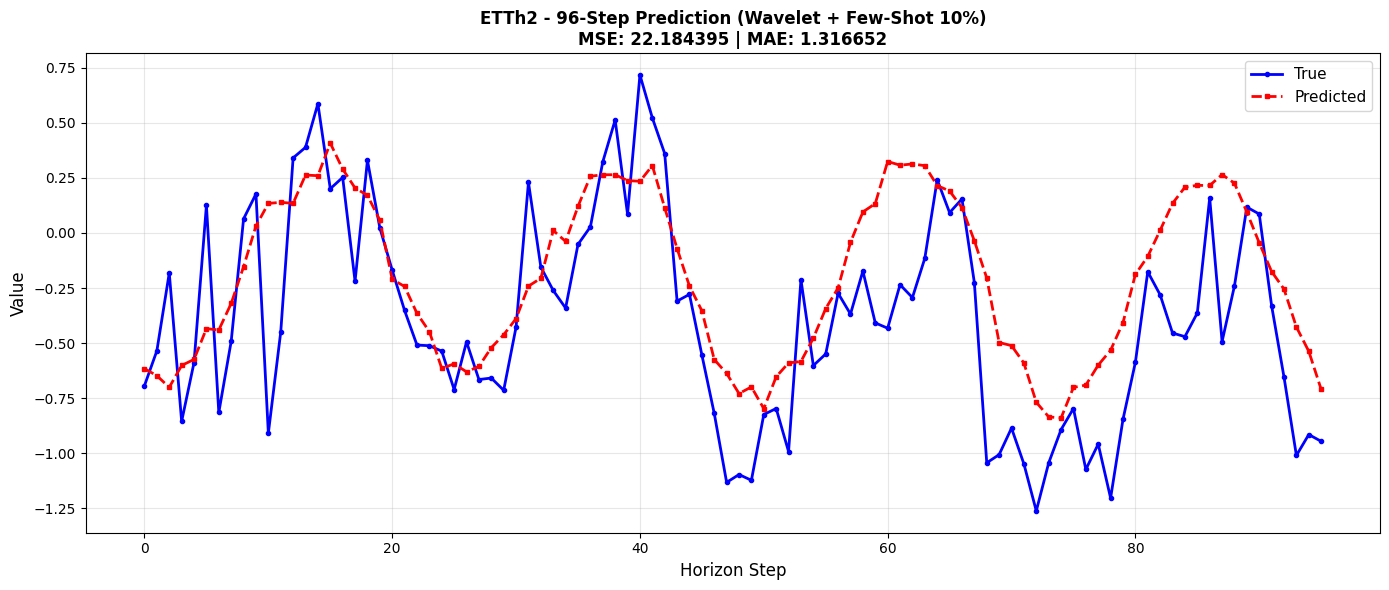


✅ Plot saved to: ETTh2_True_vs_Predicted.png


In [9]:
# ============================================================================
# QUICK RE-RUN: ETTh2 Evaluation Only (No Training)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("🔄 Running ETTh2 evaluation (this will train a fresh model)...")

# Create config
cfg = Config(
    dataset_name="ETTh2",
    experiment_mode="few_shot_10",
    pred_len=96,
    use_stl=False,
    use_wavelet=True,
    use_ssa=False,
)

# Create and train
trainer = ICTSPTrainer(cfg)
best_val = trainer.train()  # This will train
test_metrics = trainer.evaluate_and_collect_predictions()  # This gets predictions

# Generate the plot
horizon_steps = np.arange(96)
true_values = trainer.targets[0, :, 0]
pred_values = trainer.predictions[0, :, 0]

plt.figure(figsize=(14, 6))
plt.plot(horizon_steps, true_values, 'b-', label='True', linewidth=2, marker='o', markersize=3)
plt.plot(horizon_steps, pred_values, 'r--', label='Predicted', linewidth=2, marker='s', markersize=3)
plt.xlabel('Horizon Step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ETTh2 - 96-Step Prediction (Wavelet + Few-Shot 10%)\nMSE: {test_metrics["mse"]:.6f} | MAE: {test_metrics["mae"]:.6f}', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ETTh2_True_vs_Predicted.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Plot saved to: ETTh2_True_vs_Predicted.png")


ICTSP REPO-STYLE | Dataset=ETTh2 | Mode=FEW_SHOT_10 | Method=Wavelet
✅ Loaded ETTh2: (17420, 7)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
    🔧 FIXED WAVELET: wavelet=db4, level=1 (for ETTh2)
Train: (1742, 7), Val: (1742, 7), Test: (13936, 7)
Channels: 7
Windows: Train=207, Val=207, Test=12401
Parameters: 2,880,336

START TRAINING (Step-based evaluation every 200 steps)
Step    200 | Epoch  29 | LR 1.01e-04 | Val MSE 1.321711 | Best 1.321711 ✓ | Patience 0/6000
Step    400 | Epoch  58 | LR 2.01e-04 | Val MSE 1.305239 | Best 1.305239 ✓ | Patience 0/6000
Step    600 | Epoch  86 | LR 3.00e-04 | Val MSE 1.678364 | Best 1.305239   | Patience 200/6000
Step    800 | Epoch 115 | LR 4.01e-04 | Val MSE 1.681007 | Best 1.305239   | Patience 400/6000
Step   1000 | Epoch 143 | LR 5.00e-04 | Val MSE 1.743053 | Best 1.305239   | Patience 600/6000
Step   1200 | Epoch 172 | LR 2.50e-04 | Val MSE 1.772524 | Best 1.305239   | Patience 800

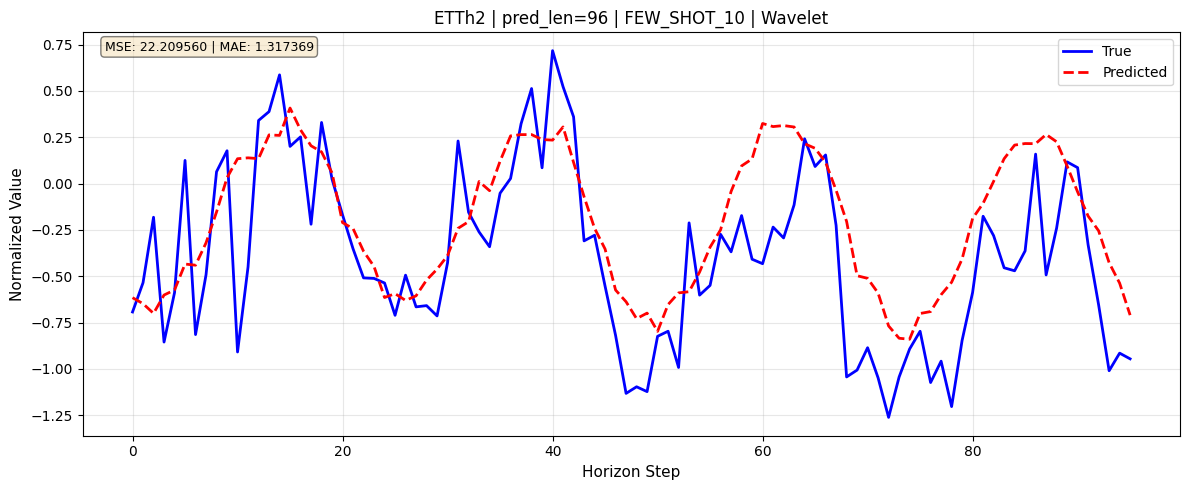


✅ Done! MSE: 22.209560, MAE: 1.317369


AttributeError: 'ICTSPTrainer' object has no attribute 'cleanup'

In [18]:
# ============================================================================
# SHORTER VERSION: Just run this cell and it will work
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Create config
cfg = Config(
    dataset_name="ETTh2",
    experiment_mode="few_shot_10",
    pred_len=96,
    use_stl=False,
    use_wavelet=True,
    use_ssa=False,
)

# Create trainer - this will train the model and get predictions
trainer = ICTSPTrainer(cfg)
best_val = trainer.train()
test_metrics = trainer.evaluate_and_collect_predictions()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(trainer.targets[0, :, 0], label="True", linewidth=2, color='blue')
plt.plot(trainer.predictions[0, :, 0], label="Predicted", linewidth=2, linestyle="--", color='red')
plt.title(f"ETTh2 | pred_len=96 | FEW_SHOT_10 | Wavelet", fontsize=12)
plt.xlabel("Horizon Step", fontsize=11)
plt.ylabel("Normalized Value", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

mse = np.mean((trainer.predictions - trainer.targets) ** 2)
mae = np.mean(np.abs(trainer.predictions - trainer.targets))
plt.text(0.02, 0.98, f'MSE: {mse:.6f} | MAE: {mae:.6f}', 
         transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("ETTh2_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Done! MSE: {mse:.6f}, MAE: {mae:.6f}")

trainer.cleanup()

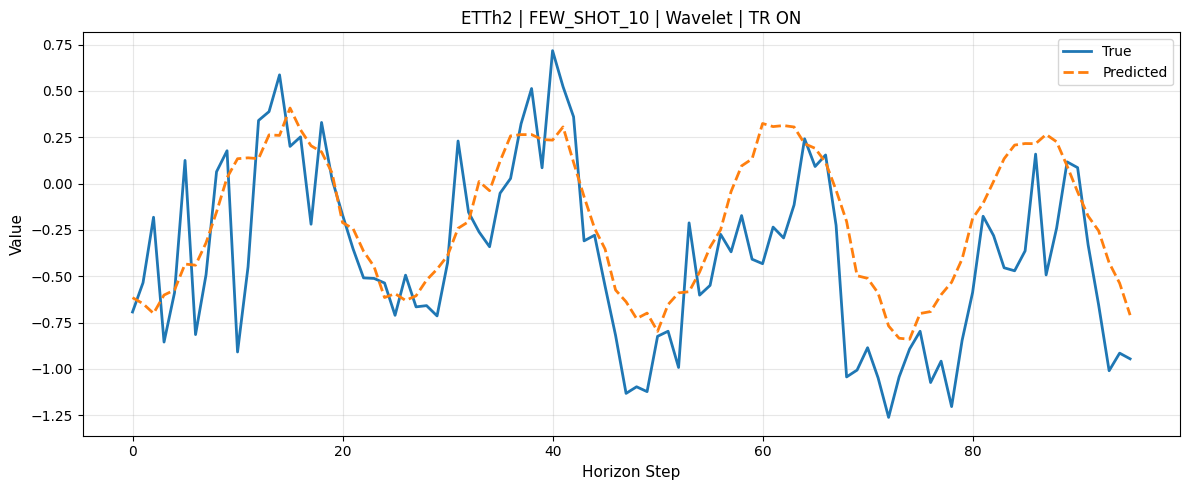

Saved: ETTh2_fewshot10_wavelet_thesis_style.png
MSE: 22.209560 | MAE: 1.317369


<Figure size 640x480 with 0 Axes>

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Use already-saved predictions from the previous run
true = trainer.targets[0, :, 0]
pred = trainer.predictions[0, :, 0]

mse = np.mean((trainer.predictions - trainer.targets) ** 2)
mae = np.mean(np.abs(trainer.predictions - trainer.targets))

plt.figure(figsize=(12, 5))

# Same style as your previous thesis plots
plt.plot(true, label="True", linewidth=2)
plt.plot(pred, label="Predicted", linewidth=2, linestyle="--")

plt.title("ETTh2 | FEW_SHOT_10 | Wavelet | TR ON", fontsize=12)
plt.xlabel("Horizon Step", fontsize=11)
plt.ylabel("Value", fontsize=11)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ETTh2_fewshot10_wavelet_thesis_style.png", dpi=150, bbox_inches="tight")
plt.show()

plt.savefig("ETTh2_fewshot10_wavelet_thesis_style.png",
            dpi=300,
            bbox_inches="tight")

print(f"Saved: ETTh2_fewshot10_wavelet_thesis_style.png")
print(f"MSE: {mse:.6f} | MAE: {mae:.6f}")

In [20]:
plt.savefig("ETTh2_fewshot10_wavelet_thesis_style.png",
            dpi=150,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

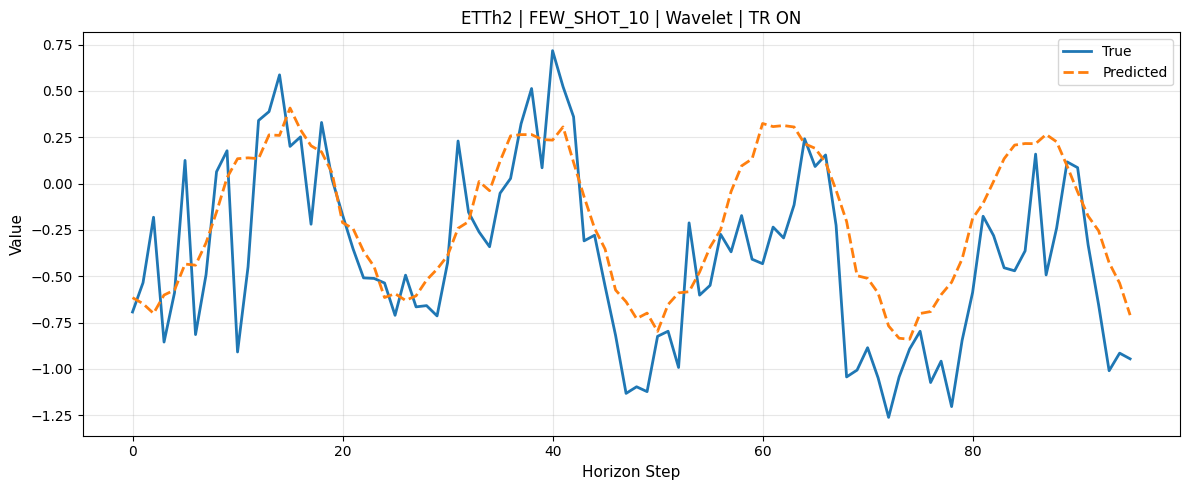

Saved plot at:
/kaggle/working/ETTh2_fewshot10_wavelet_thesis_style.png
MSE: 22.209560 | MAE: 1.317369


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Use already-trained predictions
true = trainer.targets[0, :, 0]
pred = trainer.predictions[0, :, 0]

mse = np.mean((trainer.predictions - trainer.targets) ** 2)
mae = np.mean(np.abs(trainer.predictions - trainer.targets))

plt.figure(figsize=(12, 5))

plt.plot(true, label="True", linewidth=2)
plt.plot(pred, label="Predicted", linewidth=2, linestyle="--")

plt.title("ETTh2 | FEW_SHOT_10 | Wavelet | TR ON", fontsize=12)
plt.xlabel("Horizon Step", fontsize=11)
plt.ylabel("Value", fontsize=11)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# IMPORTANT: save to Kaggle working directory
save_path = "/kaggle/working/ETTh2_fewshot10_wavelet_thesis_style.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved plot at:\n{save_path}")
print(f"MSE: {mse:.6f} | MAE: {mae:.6f}")